## Solución Prueba Data Science Riesgo de Credito Nequi - Emanuelle Moreno

En este notebook podrán encontrar la solución y el tratamiento que se le dio a la prueba enviada. Cabe aclarar que en este notebook se encuentra el paso a paso que se hizo para llegar al/los modelos, el tratamiento de datos y el razonamiento detrás, sin embargo, el codigo limpio con sus respectivos test, logs y demás está organizado en el repositorio de Github compartido. Este notebook solo cuenta la historia, retos, deducciones e inferencias hechas para la construcción de los modelos, las respuestas a las preguntas puntuales hechas se encuentran en el pdf dentro del repositorio de Github. Las instrucciones generales se encuentran en el README.md.

## Primera Inspección Visual de los Insumos

Al revisar los archivos dataset_candidato y cartera_variable_respuesta_candidato se ve que hay una diferencia en los formatos de fecha. En un principio se ve que el primero tiene un formato DD/MM/YY en el campo *application_date*  y el segundo tiene las columnas *fecha_apertura* y *fecha_corte* en formato AAAA/MM/DD, además al seguir revisando *cartera_variable* se ve que existen creditos con fechas en formato DD-MM-AAAA y por lo tanto, se procede a:

* Detectar automaticamente los registros que no conservan su formato en ambas bases
* Estandarizar el formato de las fechas en ambas bases 


## Librerias Necesarias

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import rankdata
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import average_precision_score, roc_curve

## Inconsistencia Formatos Datasets

Se crea una función que detecte automaticamente cuales registros presentan un patrón de fecha diferentes a la mayoria de sus registros, por ejemplo en el archivo de cartera se encuentra que el campo fecha_apertura está en formato AAAA-MM-DD y 20 registros con ID de solicitud diferente presentan esta inconsistencia.

In [32]:
dataset_candidato = pd.read_csv("dataset_candidato.csv", dtype=str)
cartera = pd.read_csv("cartera_variable_respuesta_candidato.csv", dtype=str)

def fechas_con_formato_distinto(df, col):
    patron = df[col].str.replace(r"\d", "9", regex=True)
    raros = patron != patron.value_counts().idxmax()
    return df.loc[raros, ["application_id", col]].assign(patron=patron[raros])

fechas_con_formato_distinto(cartera, "fecha_apertura")

,application_id,fecha_apertura,patron
921,CAND-00212,02-10-2024,99-99-9999
922,CAND-00212,02-10-2024,99-99-9999
923,CAND-00212,02-10-2024,99-99-9999
924,CAND-00212,02-10-2024,99-99-9999
1906,CAND-00436,04-05-2024,99-99-9999
...,...,...,...
17554,CAND-03987,22-11-2024,99-99-9999
17555,CAND-03987,22-11-2024,99-99-9999
17556,CAND-03987,22-11-2024,99-99-9999
17557,CAND-03987,22-11-2024,99-99-9999


En dataset_candidato se evidencia que el campo application_date algunos registros no tiene los dos digitos en los días y no cumplen con el estandar con el que viene el dataset

In [33]:
fechas_con_formato_distinto(dataset_candidato, "application_date")

,application_id,application_date,patron
3000,CAND-03713,1/10/24,9/99/99
3001,CAND-03706,1/10/24,9/99/99
3002,CAND-03632,1/10/24,9/99/99
3003,CAND-03577,1/10/24,9/99/99
3004,CAND-03932,1/10/24,9/99/99
...,...,...,...
3776,CAND-03098,9/12/24,9/99/99
3777,CAND-03164,9/12/24,9/99/99
3778,CAND-03473,9/12/24,9/99/99
3779,CAND-03624,9/12/24,9/99/99


En el campo fecha_corte del dataset de cartera no se evidencia ninguna incosistencia en los registros.

In [34]:
fechas_con_formato_distinto(cartera, "fecha_corte")

,application_id,fecha_corte,patron


## Corrección de Registros

In [35]:
## Función que corrige los problemas encontrados en el dataset de cartera

cartera = pd.read_csv("cartera_variable_respuesta_candidato.csv", dtype=str)

# Intenta primero ISO (AAAA-MM-DD) y donde falla dd-mm-AAAA
fecha_iso = pd.to_datetime(cartera["fecha_apertura"], format="%Y-%m-%d", errors="coerce")
fecha_dmy = pd.to_datetime(cartera["fecha_apertura"], format="%d-%m-%Y", errors="coerce")
fecha = fecha_iso.fillna(fecha_dmy)

# Si algo no se pudo convertir, se detiene y muestra qué filas son
assert fecha.notna().all(), cartera.loc[fecha.isna(), ["application_id", "fecha_apertura"]]


In [36]:
# DataFrame nuevo, el archivo original no se modifica
cartera_limpia = cartera.copy()
cartera_limpia["fecha_apertura"] = fecha.dt.strftime("%Y-%m-%d")

Validación con un registro particular para ver que el ajuste fue bien aplicado

In [37]:
cartera_limpia[cartera_limpia['application_id']=='CAND-00212']

,application_id,fecha_apertura,fecha_corte,altura_mora,saldo_capital
921,CAND-00212,2024-10-02,2024-11-01,30,454209
922,CAND-00212,2024-10-02,2024-12-01,60,445477
923,CAND-00212,2024-10-02,2024-12-31,90,431866
924,CAND-00212,2024-10-02,2025-01-30,118,423602


Función que corrige las inconsistencia en fecha del dataset de candidato y además estandariza la fecha a AAAA-MM-DD para dejar ambas bases con el mismo formato

In [38]:
# Solo application_date se lee como texto, el resto de columnas conserva su tipo
candidato = pd.read_csv("dataset_candidato.csv", dtype={"application_date": str})

# Acepta días de uno o dos dígitos (1/10/24 y 01/10/24)
fecha = pd.to_datetime(candidato["application_date"], format="%d/%m/%y", errors="coerce")

# Si algo no se pudo convertir, se detiene y muestra qué filas son
assert fecha.notna().all(), candidato.loc[fecha.isna(), ["application_id", "application_date"]]

# DataFrame nuevo, el archivo original no se modifica
datos_limpio = candidato.copy()
datos_limpio["application_date"] = fecha.dt.strftime("%Y-%m-%d")

Validación con un registro particular para ver que el ajuste quedó bien

In [39]:
datos_limpio[datos_limpio['application_id']=='CAND-03393']

,application_id,application_date,age,sexo,monthly_income_declared,app_tenure_months,avg_monthly_topups,num_transactions_last_90d,pct_p2p_transfers,device_price_tier,has_bureau_record,bureau_score,utility_payment_ontime_rate,telco_payment_ontime_rate,digital_engagement_score,monto_bono_referidos,requested_amount,product_type,disbursed_flag
3717,CAND-03393,2024-12-05,38,M,3443676,38,3541,22,0.364,1,True,597.0,0.855,0.756,34.1,0,450265,avance_efectivo,True


## Unificación de bases

Ahora vamos a proceder a unificar variables de ambas tablas para poder analizar la distribución de diferentes rangos de mora. Si bien en este primer paso solo se obtienen los creditos que fueron desembolsados, y por tanto, aparecen en ambas bases (disbursed_flag = TRUE) posteriormente los uniremos con las solicitudes hechas pero no desembolsadas. Este primer analisis se hace con el fin de conocer que tantos registros tenemos que sean validos para crear los vectores de mora y así construir nuestra variable objetivo. 

In [40]:
# Cruce: todas las filas de cartera + 3 campos de datos_limpios (y application_date)
cartera_analisis = cartera_limpia.merge(
    datos_limpio[["application_id", "application_date", "product_type", "disbursed_flag"]],
    on="application_id",
    how="left",
    validate="many_to_one",
)

# Orden de filas: de la apertura más antigua a la más reciente
cartera_analisis = (
    cartera_analisis
    .sort_values(["fecha_apertura", "application_id", "fecha_corte"])
    .reset_index(drop=True)
)

# Orden de columnas
cartera_analisis = cartera_analisis[
    [
        "application_id",
        "application_date",
        "fecha_apertura",
        "fecha_corte",
        "altura_mora",
        "saldo_capital",
        "product_type",
        "disbursed_flag",
    ]
]

In [41]:
cartera_analisis

,application_id,application_date,fecha_apertura,fecha_corte,altura_mora,saldo_capital,product_type,disbursed_flag
0,CAND-01966,2024-01-01,2024-01-04,2024-02-03,0,1009620,avance_efectivo,True
1,CAND-01966,2024-01-01,2024-01-04,2024-03-04,0,949791,avance_efectivo,True
2,CAND-01966,2024-01-01,2024-01-04,2024-04-03,0,889961,avance_efectivo,True
3,CAND-01966,2024-01-01,2024-01-04,2024-05-03,0,792059,avance_efectivo,True
4,CAND-02825,2024-01-01,2024-01-04,2024-02-03,0,425501,avance_efectivo,True
...,...,...,...,...,...,...,...,...
18164,CAND-03620,2024-12-31,2025-01-28,2025-04-28,30,747062,libre_inversion,True
18165,CAND-03620,2024-12-31,2025-01-28,2025-05-28,60,729750,libre_inversion,True
18166,CAND-03295,2024-12-30,2025-01-29,2025-02-28,0,433294,libre_inversion,True
18167,CAND-03295,2024-12-30,2025-01-29,2025-03-30,0,390322,libre_inversion,True


## Analisis Exploratorios de esta primera base

Decidí primero entender la base de cartera dado que con esta armaré la variable objetivo y cuando determine el mejor vector de mora si haré la exploración de las variables explicativas. En una primera etapa revisé de manera visual la tabla tratando de encontrar patrones o particularidades que requieran atención especial sin necesidad de hacer un codigo para rectificar la calidad de los datos y encontré lo siguiente: 

* Existen clientes que estando en mora el saldo_capital va disminuyendo a lo largo del tiempo (por ejemplo CAND-00139), lo cual podria significar que está pagando menos que el pago minimo o que paga menos que la cuota fija que se pactó, si bien el capital baja muy poco no representa un compartamiento normal dentro de una deuda dado que lo primero que se pagan los intereses y al no cubrir la totalidad lo mayoria va a interes, el restante a capital y aún así estar en mora. Esta variable no la tendré en cuenta para el modelo dado que no representa o conjuga en un sentido de negocio con la variable objetivo y además al haber particularidades entre los clientes podria generar confusión al modelo. Tambien se encontró varios ID mal nombrados y sin datos y por lo tanto, se eliminaron (ejemplo:CAND-PH0055).

* Cuando la mora supera los 90 días el calculo de la variable altura_mora empieza a ser errada, por ejemplo, con el mismo cliente del caso anterior pasa de 90 a 107 días en el siguiente mes cuando debio ser 120. Entendiendo que con esta variable se construirá la variable objetivo decidí no eliminar aquellos registros sino estandarizar los clientes con 90 días de mora o más con una marcación 90+, eso tambien entendiendo que una mora de esta altura se vuelve una cartera castiga o incluso llegar a hacer venta de cartera y la entidad financiera muchas veces saca estos creditos de sus activos. 

* Dentro de la base hay muchos clientes que se rodaron desde el primer mes y nunca se auto curaron o pagaron sus obligaciones o bajaron su altura de mora, esto en particular podria tener varios puntos de vista: la primera y la más probable para mi, es que eso casos se traten de fraude. Esta modalidad de fraude es común en los bancos que un cliente tenga un buen perfil o sea propenso a credito, pero despues de desembolsado no pagó, no contesta a las casas de cobranzas y tampoco se acerca a negociar su deuda, ese evento de fraude es muy dificil de modelar y en mi opinión es más un problema de riesgo de fraude que de default, más adelante explico las cifras, pero aún así no voy a eliminar estos registros porque con la información dada no tengo como validar que esto realmente sea fraude y perderia información para construir la variable objetivo. Otra causa podria ser cambio en sus ingresos especialmente si es independiente o la menos probable pero dentro de las posibles es fallecimiento del cliente. 

In [42]:
## Número de creditos unicos en la tabla analisis_cartera
len(cartera_analisis['application_id'].unique())

4052

In [43]:
## Número de creditos unicos que tienen nombres irregulares y sin data (ejemplo: CAND-PH0050)
patron = r'^CAND-PH\d+'
cartera_analisis.loc[cartera_analisis['application_id'].str.contains(patron, regex=True, na=False), 'application_id'].nunique()


122

In [44]:
## Eliminar los registros que cumplen el patron
cartera_analisis = cartera_analisis[~cartera_analisis['application_id'].str.contains(patron, regex=True, na=False)]


In [45]:
## Cantidad de creditos despues de la limpieza
len(cartera_analisis['application_id'].unique())

3930

## Construcción de variable objetivo

El siguiente codigo retorna una tabla que contiene la cantidad de creditos por producto y por altura de mora. El objetivo es poder analizar si existe alguna diferencia notable entre las productos, alturas de mora y el campo pct mide el porcentaje de créditos de cada producto que alcanzaron cierto nivel de mora en algún momento de su historia.

In [46]:
df = cartera_analisis[cartera_analisis["product_type"].notna()].copy()   # 3.930 créditos
df["altura_mora"] = df["altura_mora"].astype(int)

# Una fila por crédito: producto y mora máxima alcanzada
por_credito = df.groupby("application_id").agg(
    product_type=("product_type", "first"),
    mora_max=("altura_mora", "max"),
)
por_credito["nivel"] = pd.cut(
    por_credito["mora_max"], bins=[-1, 29, 59, 89, 999], labels=["0", "30", "60", "90+"] ## Aca se marcan los clientes 90+
)

# Conteos por producto y nivel máximo de mora
consolidado = pd.crosstab(
    por_credito["product_type"], por_credito["nivel"], margins=True, margins_name="Total"
)
consolidado.columns = ["mora_0", "mora_30", "mora_60", "mora_90+", "creditos"]

# Porcentajes de interés
consolidado["pct_>=60"] = ((consolidado["mora_60"] + consolidado["mora_90+"]) / consolidado["creditos"] * 100).round(1)
consolidado["pct_90+"] = (consolidado["mora_90+"] / consolidado["creditos"] * 100).round(1)

consolidado = consolidado[["creditos", "mora_0", "mora_30", "mora_60", "mora_90+", "pct_>=60", "pct_90+"]]
consolidado

,creditos,mora_0,mora_30,mora_60,mora_90+,pct_>=60,pct_90+
product_type,,,,,,,
avance_efectivo,983,613,215,61,94,15.8,9.6
compra_cartera,793,500,167,34,92,15.9,11.6
libre_inversion,2154,1358,465,108,223,15.4,10.4
Total,3930,2471,847,203,409,15.6,10.4


De la tabla anterior podemos sacar las siguientes conclusiones: 

* No es apropiado segmentar el default por producto dado que los porcentajes por cada producto son muy similares, están en $\pm 0.2%$ , es mejor agregar tipo de producto como variable explicativa (de momento).

* Conservar todos los productos como uno solo para la variable objetivo hace que no perdamos registros o queden clases muy desbalanceados, por ejemplo libre inversión tiene $2154$ creditos frente a $983$ y $793$ de los demás productos.

* Cerca del $\frac{613 + 500 + 1358}{3930}\times 100 = 62 \% $ del total de la cartera se encuentra en mora 0 (sanos), mora 30 cerca del $21.55 \%$, mora 60 cerca del $5.16 \%$ y mora 90+ el $10.40 \%$    

## Selección de umbral para variable objetivo - Matriz de Transición

Ahora vamos a ver que altura de mora conviene más para marcar un cliente como un default o no. El siguiente codigo lo que hace es medir que tanto se ruedan los clientes a medida que pasa el tiempo, por ejemplo si un cliente llega a mora 30 pero se curó entonces la pregunta es ¿lo cuentó como default? y así con toda las alturas de moras para ver donde se concentra más el rodamiento o impago de las obligaciones.

In [47]:
df = cartera_analisis[cartera_analisis["product_type"].notna()].copy()  
df["altura_mora"] = df["altura_mora"].astype(int)
df = df.sort_values(["application_id", "fecha_corte"])

# Nivel de mora en cada corte y nivel en el corte siguiente del mismo crédito
df["nivel"] = pd.cut(df["altura_mora"], bins=[-1, 29, 59, 89, np.inf], labels=["0", "30", "60", "90+"])
df["nivel_siguiente"] = df.groupby("application_id")["nivel"].shift(-1)

# Solo filas que tienen un corte siguiente (se descarta el último corte de cada crédito)
transiciones = df.dropna(subset=["nivel_siguiente"])

conteos = pd.crosstab(transiciones["nivel"], transiciones["nivel_siguiente"])
porcentajes = pd.crosstab(transiciones["nivel"], transiciones["nivel_siguiente"], normalize="index").mul(100).round(1)
porcentajes["transiciones"] = conteos.sum(axis=1)

In [48]:
porcentajes

nivel_siguiente,0,30,60,90+,transiciones
nivel,,,,,
0,90.0,10.0,0.0,0.0,11522
30,51.8,0.0,48.2,0.0,1321
60,0.0,10.5,0.0,89.5,474
90+,0.0,0.0,7.5,92.5,371


La matriz de transición nos entrega muchisima información sobre donde se están rodando los clientes en esta cartera en particular y decide en donde hacer los cortes para construir generar la marca de nuestra variable objetivo. Se concluye que: 

* nivel 0: El $90 \% $ de los clientes que están sanos se mantienen sanos y solo el $ 10 \% $ se rueda a mora 30.
* nivel 30: El $51.8 \% $ de los clientes que están en mora 30 se curan (se ponen al día) y el $ 48.2 \% $ se rueda a mora 60.
* nivel 60: El $10.5 \% $ de los clientes que están en mora 60 pagan un mes y vuelven a mora 30 y el $89.5 \% $ se rueda a mora 90+.
* nivel 90+: El $7.5 \% $ de los clientes que están en mora 90+ pagan un mes y vuelven a mora 60 y el $92.5 \% $ se rueda más.

Algo muy curioso de esta cartera es que tiene unos huecos muy marcados, por ejemplo los clientes de mora 30 y 60 se ruedan un nivel más alto o se devuelven un nivel, pero no se mantienen en ese mismo estado, literalmente ningún cliente se queda en el mismo estado en ninguno de estos dos, pero creo que es más por la generación aleatoria de los datos lo cual en general complica mucho las inferencias y transformaciones hecha sobre los datos entregados.

De acuerdo a la matriz de transición la opción más viable es seleccionar la mora 60, pero nos falta saber cual ventana de tiempo. Recordemos que por lo general los modelos de default responden a una pregunta muy particular y es "Cual es la probabilidad de impago de 60 días en los X (ventana) meses posteriores al desembolso ?". Esto va a depender de que tanta data nos queda despues de construir este vector, validemos esto:


In [49]:
df = cartera_analisis[cartera_analisis["product_type"].notna()].copy()   # 3.930 créditos
df["altura_mora"] = df["altura_mora"].astype(int)
df["application_date"] = pd.to_datetime(df["application_date"])
df = df.sort_values(["application_id", "fecha_corte"])
df["corte_n"] = df.groupby("application_id").cumcount() + 1        

# Una fila por crédito: fecha de solicitud y número de cortes observados
por_credito = df.groupby("application_id").agg(
    application_date=("application_date", "first"),
    n_cortes=("corte_n", "max"),
)

# Split temporal por fecha de solicitud
por_credito["split"] = pd.cut(
    por_credito["application_date"],
    bins=pd.to_datetime(["2023-12-31", "2024-08-31", "2024-10-31", "2024-12-31"]),
    labels=["train", "valid", "test"],
)

UMBRAL = 60
filas = []
for k in [3, 4, 5, 6]:
    # Mora máxima dentro de los primeros k cortes
    mora_k = df[df["corte_n"] <= k].groupby("application_id")["altura_mora"].max()

    # Solo créditos con al menos k cortes observados
    usados = por_credito[por_credito["n_cortes"] >= k].copy()
    usados["default"] = (mora_k.loc[usados.index] >= UMBRAL).astype(int)

    fila = {
        "ventana": f"{k} cortes ({k * 30} d)",
        "creditos": len(usados),
        "excluidos": len(por_credito) - len(usados),
        "eventos": usados["default"].sum(),
        "tasa_%": round(usados["default"].mean() * 100, 1),
    }
    for s in ["train", "valid", "test"]:
        fila[f"eventos_{s}"] = usados.loc[usados["split"] == s, "default"].sum()
    filas.append(fila)

tabla = pd.DataFrame(filas)
tabla

,ventana,creditos,excluidos,eventos,tasa_%,eventos_train,eventos_valid,eventos_test
0,3 cortes (90 d),3930,0,415,10.6,254,68,93
1,4 cortes (120 d),2938,992,388,13.2,243,55,90
2,5 cortes (150 d),1937,1993,292,15.1,189,42,61
3,6 cortes (180 d),953,2977,159,16.7,102,25,32


Al alargar la ventana de 3 a 4 cortes se pierde el $25 \%$ de los créditos y también eventos (415 a 388). A 5 y 6 cortes la muestra queda muy reducida. Los 3 cortes (90 días) son la ventana más larga que conserva todos los créditos.

Tambien hay que tener en cuenta que si se excluyen creditos los que tienen solo 3 cortes son los más riesgosos al inicio: el $14,8 \%$ de ellos llega a 60 en sus primeros 3 cortes, contra 10,2%, 9,2% y 7,9% de los que tienen 4, 5 y 6. Exigir 4 cortes los dejaría fuera y la tasa bajaría artificialmente de 10,6% a 9,1%. Con 3 cortes no se excluye ninguno por la longitud de su historia.

Tambien necesitamos conservar data teniendo en cuenta que hay que dividir en tres el dataset completo y cada que vez que vayamos a calcular metricas sobre cada partición será más reducida y menos diciente o muy volatiles las metricas. 

* Por lo tanto el/los modelos serán construidos para responder a la pregunta: Dado un cliente que solicita un credito ¿cuál es la probabilidad de que, una vez desembolsado, alcance una mora de 60 días o más en alguno de sus primeros 90 días (3 cortes)?

## Marcación de variable objetivo 

De acuerdo a la selección de altura de mora y selección de ventana de tiempo procedemos a generar la marcación de la variable objetivo para ahora si empezar a hacer la analitica sobre las variables explicativas, transformaciones necesarias y construir los modelos de clasificación. Debemos tener en cuenta que como nosotros iniciamos la construcción de la variable objetivo con la tabla de cartera, las solicitudes de credito que no fueron desembolsadas (70) no tenemos como generarles la marcación y por eso no aparecen en esta base final, al igual que las solicitudes que tenian como identificación CAND-PH y que fueron eliminadas al no tener data en la tabla de cartera.

In [50]:
UMBRAL_MORA = 60
VENTANA_CORTES = 3

df = cartera_analisis[cartera_analisis["product_type"].notna()].copy()   # 3.930 créditos
df["altura_mora"] = df["altura_mora"].astype(int)
df = df.sort_values(["application_id", "fecha_corte"])
df["corte_n"] = df.groupby("application_id").cumcount() + 1

# Todos los créditos deben tener la ventana completa
assert df.groupby("application_id")["corte_n"].max().min() >= VENTANA_CORTES

# Variable objetivo: 1 si la mora máxima en los primeros 3 cortes es >= 60
mora_ventana = df[df["corte_n"] <= VENTANA_CORTES].groupby("application_id")["altura_mora"].max()
objetivo = (mora_ventana >= UMBRAL_MORA).astype(int).rename("default_60_90d").reset_index()

# Base completa: una fila por crédito, todas las columnas de datos_limpios + objetivo
base_modelo = datos_limpio.merge(objetivo, on="application_id", how="inner", validate="one_to_one")

In [51]:
base_modelo.head()

,application_id,application_date,age,sexo,monthly_income_declared,app_tenure_months,avg_monthly_topups,num_transactions_last_90d,pct_p2p_transfers,device_price_tier,has_bureau_record,bureau_score,utility_payment_ontime_rate,telco_payment_ontime_rate,digital_engagement_score,monto_bono_referidos,requested_amount,product_type,disbursed_flag,default_60_90d
0,CAND-02052,2024-01-01,22,M,1149897,7,14838,2,0.712,3,False,NaN,0.524,0.728,52.7,0,1160359,compra_cartera,True,0
1,CAND-00752,2024-01-01,33,M,616023,11,51171,3,0.288,3,False,NaN,0.822,0.938,50.3,0,273514,libre_inversion,True,0
2,CAND-00542,2024-01-01,43,M,3064570,7,31961,6,0.360,1,False,NaN,0.547,0.915,81.2,0,283447,libre_inversion,True,0
3,CAND-01204,2024-01-01,34,H,1817355,7,43710,3,0.515,2,False,NaN,0.501,0.922,59.6,0,741165,libre_inversion,True,0
4,CAND-02825,2024-01-01,30,M,879261,5,37064,2,0.544,4,True,530.0,0.697,0.738,19.5,0,167681,avance_efectivo,True,0


## Formateo tipos de campos

Antes de iniciar con la etapa de modelamiento debemos seleccionar como vamos a manejar cada variable, determinando su tipo (númerica, booleana, categorica, etc), para luego si revisar si existen datos faltantes, atipicos, distribuciones, boxplot y demás. 

In [52]:
ENTERAS = ["age", "app_tenure_months", "avg_monthly_topups", "num_transactions_last_90d",
"monto_bono_referidos", "requested_amount"]

CONTINUAS = ["monthly_income_declared", "pct_p2p_transfers", "bureau_score",    
"utility_payment_ontime_rate", "telco_payment_ontime_rate", "digital_engagement_score"]

BOOLEANAS = ["has_bureau_record", "disbursed_flag"]

CATEGORICAS = ["sexo", "product_type"]

ORDINALES = {"device_price_tier": [1, 2, 3, 4, 5]}   # de menor a mayor gama

# Rangos esperados (solo se reportan, no se corrigen)
RANGOS = {
    "age": (18, 65), "pct_p2p_transfers": (0, 1),
    "utility_payment_ontime_rate": (0, 1), "telco_payment_ontime_rate": (0, 1),
    "digital_engagement_score": (0, 100), "bureau_score": (300, 900),
}


def estandarizar_tipos(base: pd.DataFrame) -> pd.DataFrame:
    """Asigna el tipo correcto a cada variable. No imputa, no agrupa y no escala."""

    df = base.copy()

    df["application_date"] = pd.to_datetime(df["application_date"], format="%Y-%m-%d")

    # Ingreso: viene como texto. Lo corrupto pasa a NaN y se deja una bandera.
    ingreso = pd.to_numeric(df["monthly_income_declared"], errors="coerce")
    df["ingreso_corrupto"] = ingreso.isna() & df["monthly_income_declared"].notna()
    df["monthly_income_declared"] = ingreso

    for col in ENTERAS:
        df[col] = df[col].astype("int64")
    for col in CONTINUAS:
        df[col] = df[col].astype("float64")
    for col in BOOLEANAS:
        df[col] = df[col].astype(bool)

    for col in CATEGORICAS:
        df[col] = df[col].astype("string").str.strip().astype("category")
    for col, niveles in ORDINALES.items():
        df[col] = df[col].astype(pd.CategoricalDtype(niveles, ordered=True))

    df["default_60_90d"] = df["default_60_90d"].astype("int8")
    return df

In [53]:
base_tipada = estandarizar_tipos(base_modelo)

In [54]:
base_tipada.shape  

(3930, 21)

## Generación de splits (train, valid, test)

In [55]:
FIN_TRAIN = "2024-08-31"
FIN_VALID = "2024-10-31"

# Marca cada crédito según su fecha de solicitud
base_tipada["split"] = np.select(
    [base_tipada["application_date"] <= FIN_TRAIN,
     base_tipada["application_date"] <= FIN_VALID],
    ["train", "valid"],
    default="test",
)
base_tipada["split"] = pd.Categorical(base_tipada["split"], categories=["train", "valid", "test"], ordered=True)

# Un dataframe por split
train = base_tipada[base_tipada["split"] == "train"].copy()
valid = base_tipada[base_tipada["split"] == "valid"].copy()
test = base_tipada[base_tipada["split"] == "test"].copy()

# Resumen para verificar la partición
resumen_split = base_tipada.groupby("split", observed=True).agg(
    creditos=("application_id", "size"),
    eventos=("default_60_90d", "sum"),
    tasa_default=("default_60_90d", "mean"),
    fecha_min=("application_date", "min"),
    fecha_max=("application_date", "max"),
)
resumen_split["tasa_default"] = (resumen_split["tasa_default"] * 100).round(1)
resumen_split

,creditos,eventos,tasa_default,fecha_min,fecha_max
split,,,,,
train,2651,254,9.6,2024-01-01,2024-08-31
valid,631,68,10.8,2024-09-01,2024-10-31
test,648,93,14.4,2024-11-01,2024-12-31


## Analítica de variables y modelamiento

A partir de aquí trabajamos únicamente con `train`, `valid` y `test` ya generados. Las reglas que seguimos son las que se definieron al partir los datos:

* Todo lo que se "aprende" de los datos (cortes de winsorización, bins, WoE, coeficientes) se calcula **solo con train** y luego se aplica a valid y test.
* `valid` se usa para decidir (qué variables entran, qué modelo se queda).
* `test` se usa **una sola vez** al final para medir el modelo elegido. En las secciones de estabilidad (PSI, evolución mensual) aparecen datos de test solo como diagnóstico; ninguna decisión de variables o de modelo se tomó mirando test.

Primero se definen las librerías, constantes y los colores de las gráficas (azul = train, naranja = valid, verde = test).

In [56]:
Y = "default_60_90d"
SEED = 42
N_BINS, N_PERM = 6, 200
COLORES = {"train": "#2a78d6", "valid": "#eb6834", "test": "#1baf7a", "gris": "#9a9893", "texto": "#52514e", "violeta": "#4a3aa7"}

plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
"grid.alpha": 0.25, "grid.linewidth": 0.6, "axes.titlesize": 10, "axes.titleweight": "bold",
"axes.labelsize": 9, "xtick.labelsize": 8, "ytick.labelsize": 8, "legend.frameon": False,
"legend.fontsize": 8, "figure.dpi": 100})

## Calidad de datos en train

Revisamos nulos, duplicados y valores pegados a los extremos de los rangos esperados antes de transformar nada.

In [57]:
# Porcentaje de nulos por variable en train
nulos = (train.isna().mean() * 100).round(1)
nulos[nulos > 0]

monthly_income_declared         1.2
bureau_score                   54.7
utility_payment_ontime_rate     6.5
telco_payment_ontime_rate       6.1
dtype: float64

Los nulos más importantes son bureau_score (54.7%), utility_payment_ontime_rate (6.5%) y telco_payment_ontime_rate (6.1%). Los otros nulos son pocos (ingreso 1.2%). El 54.7% de `bureau_score` no es un dato perdido: es la proporción de clientes sin historial en buró (thin file), así que el nulo **es información** y no se imputa con un promedio.

In [58]:
# Duplicados y valores pegados a los extremos del rango (train)
print("IDs duplicados:", train["application_id"].duplicated().sum())
print("Ingresos corruptos (quedaron nulos):", train["ingreso_corrupto"].sum())
print("age == 18:", (train["age"] == 18).sum(), "| app_tenure_months == 60:", (train["app_tenure_months"] == 60).sum(), "| ingreso == 300.000:", (train["monthly_income_declared"] == 300000).sum())
print("digital_engagement_score en 0 y en 100:", (train["digital_engagement_score"] == 0).sum(), "y", (train["digital_engagement_score"] == 100).sum())
print("requested_amount menor a 10.000:", (train["requested_amount"] < 10000).sum())
print("Clientes con bono de referidos:", (train["monto_bono_referidos"] > 0).sum(), "de", len(train))
sin_trx = train["num_transactions_last_90d"] == 0
print("Clientes con 0 transacciones:", sin_trx.sum(), "| % P2P promedio de esos clientes:", round(train.loc[sin_trx, "pct_p2p_transfers"].mean(), 2))
print("bureau_score nulo coincide con has_bureau_record = False:", (train["bureau_score"].isna() == ~train["has_bureau_record"]).all())

IDs duplicados: 0
Ingresos corruptos (quedaron nulos): 33
age == 18: 131 | app_tenure_months == 60: 33 | ingreso == 300.000: 3
digital_engagement_score en 0 y en 100: 21 y 16
requested_amount menor a 10.000: 17
Clientes con bono de referidos: 56 de 2651
Clientes con 0 transacciones: 243 | % P2P promedio de esos clientes: 0.4
bureau_score nulo coincide con has_bureau_record = False: True


Resultados de la revisión:

* No hay IDs duplicados y el nulo de bureau_score coincide exactamente con has_bureau_record = False.
* Hay 33 ingresos corruptos que ya quedaron nulos en la limpieza y apenas 3 clientes con ingreso de 300.000 (el mínimo), así que no hay un "piso" artificial relevante.
* age == 18 (131 clientes) y app_tenure_months == 60 (33) son los límites del rango son valores posibles y se dejan.
* 243 clientes tienen 0 transacciones en 90 días y su % P2P promedio es 0.40, es decir, ese porcentaje no tiene sentido con 0 transacciones (se prueba una versión que lo anula más adelante).
* Solo 56 de 2.651 clientes tienen bono de referidos, es una variable casi vacía.

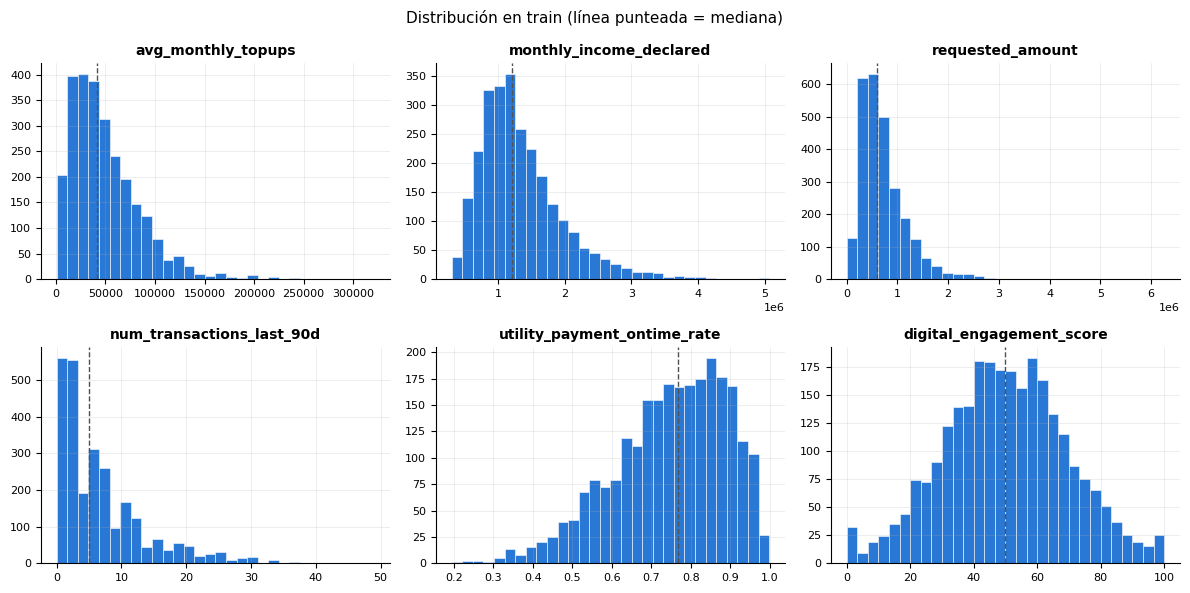

In [59]:
# Distribución de las variables numéricas principales (train)
VARS_NUM = ["avg_monthly_topups", "monthly_income_declared", "requested_amount",
            "num_transactions_last_90d", "utility_payment_ontime_rate", "digital_engagement_score"]

fig, axes = plt.subplots(2, 3, figsize=(12, 6))
for ax, v in zip(axes.ravel(), VARS_NUM):
    ax.hist(train[v].dropna(), bins=30, color=COLORES["train"], edgecolor="white", linewidth=0.4)
    ax.axvline(train[v].median(), color=COLORES["texto"], linestyle="--", linewidth=1)
    ax.set_title(v)
fig.suptitle("Distribución en train (línea punteada = mediana)", fontsize=11)
plt.tight_layout()

avg_monthly_topups, monthly_income_declared, requested_amount y num_transactions_last_90d tienen asimetría a la derecha (la mediana está muy por debajo de la media). Los porcentajes y puntajes (utility_payment_ontime_rate, digital_engagement_score) están acotados y no necesitan tratamiento.

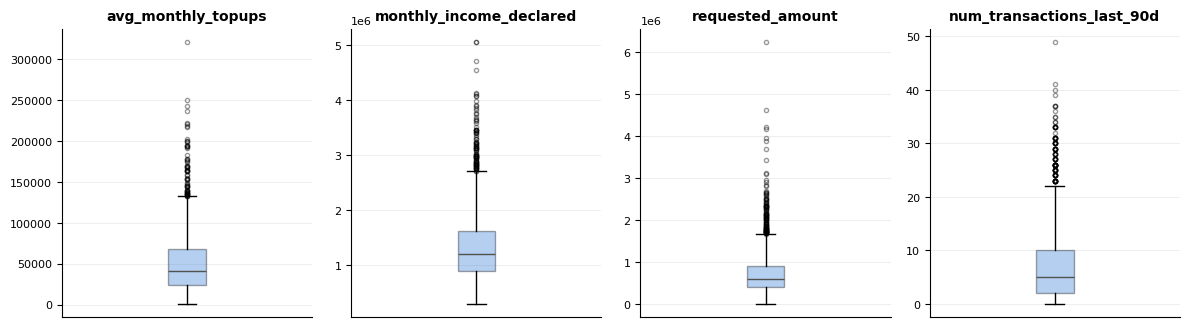

In [60]:
# Boxplots de las variables de monto y conteo (train)
fig, axes = plt.subplots(1, 4, figsize=(12, 3.5))
for ax, v in zip(axes, ["avg_monthly_topups", "monthly_income_declared", "requested_amount", "num_transactions_last_90d"]):
    ax.boxplot(train[v].dropna(), patch_artist=True, boxprops=dict(facecolor=COLORES["train"], alpha=0.35),
               medianprops=dict(color=COLORES["texto"]), flierprops=dict(marker="o", markersize=3, alpha=0.4))
    ax.set_title(v)
    ax.set_xticks([])
plt.tight_layout()

Los boxplots confirman la cola derecha larga en las cuatro variables de monto y conteo. Antes de recortar, hay que ver si esas colas tienen un comportamiento de default diferente.

## Atípicos y winsorización

Calculamos los percentiles 1 y 99 con train y miramos la tasa de default de cada cola contra el resto. Si una cola tiene un comportamiento distinto, recortarla borra información; si se comporta como el resto, recortarla solo protege de valores extremos.

In [61]:
# Tasa de default en las colas de cada variable de monto (percentiles de train)
VARS_WINSOR = ["avg_monthly_topups", "monthly_income_declared", "requested_amount", "num_transactions_last_90d"]

filas = []
for v in VARS_WINSOR:
    p1, p99 = train[v].quantile([0.01, 0.99])
    baja, alta = train[v] <= p1, train[v] >= p99
    filas.append({"variable": v, "p1": p1, "p99": p99, "maximo": train[v].max(),
    "n_cola_baja": baja.sum(), "default_cola_baja_%": round(train.loc[baja, Y].mean() * 100, 1),
    "n_cola_alta": alta.sum(), "default_cola_alta_%": round(train.loc[alta, Y].mean() * 100, 1),
    "default_resto_%": round(train.loc[~baja & ~alta, Y].mean() * 100, 1)})
tabla_colas = pd.DataFrame(filas).set_index("variable")
tabla_colas

,p1,p99,maximo,n_cola_baja,default_cola_baja_%,n_cola_alta,default_cola_alta_%,default_resto_%
variable,,,,,,,,
avg_monthly_topups,4052.50,168190.50,321154.0,27,25.9,27,3.7,9.5
monthly_income_declared,434409.76,3423345.97,5067733.0,27,7.4,27,11.1,9.6
requested_amount,109864.50,2440568.50,6258154.0,27,3.7,27,3.7,9.7
num_transactions_last_90d,0.00,31.00,49.0,243,12.3,29,17.2,9.2


La cola **baja** de avg_monthly_topups es información, no ruido: el 1% de clientes con menos recargas (<= 4.052) tiene 25.9% de default contra 9.5% del resto. Por eso **no se recorta la cola baja** de ninguna variable. La cola alta de las variables de monto no tiene un default distinto (3.7% recargas, 3.7% monto, 11.1% ingreso, sobre 27 clientes cada una) y solo aporta valores extremos (recargas hasta 321.154, monto solicitado hasta 6,2 millones), así que se winsoriza en el p99.

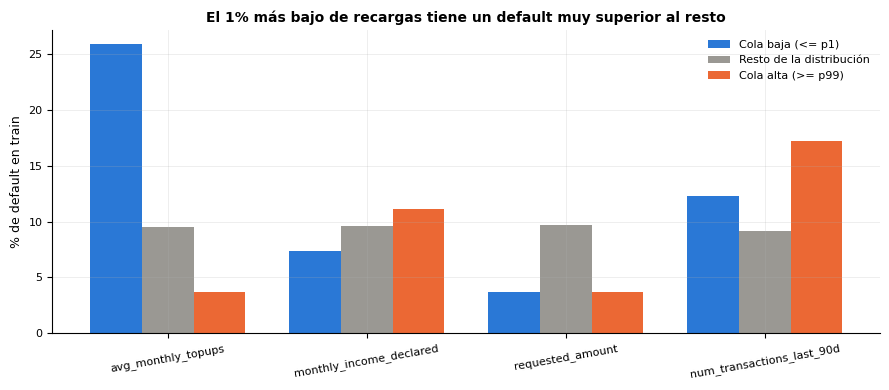

In [62]:
# Misma tabla en gráfico: tasa de default en cola baja, resto y cola alta
x = np.arange(len(tabla_colas)); ancho = 0.26
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(x - ancho, tabla_colas["default_cola_baja_%"], ancho, color=COLORES["train"], label="Cola baja (<= p1)")
ax.bar(x, tabla_colas["default_resto_%"], ancho, color=COLORES["gris"], label="Resto de la distribución")
ax.bar(x + ancho, tabla_colas["default_cola_alta_%"], ancho, color=COLORES["valid"], label="Cola alta (>= p99)")
ax.set_xticks(x); ax.set_xticklabels(tabla_colas.index, rotation=10)
ax.set_ylabel("% de default en train"); ax.set_title("El 1% más bajo de recargas tiene un default muy superior al resto")
ax.legend()
plt.tight_layout()

In [63]:
# Winsorización de la cola alta (p99). Los limites se calculan SOLO con train y se aplican a valid y test
LIMITE_P99 = {v: train[v].quantile(0.99) for v in VARS_WINSOR}

def preparar(df):
    d = df.copy()
    for v, limite in LIMITE_P99.items():
        d[v] = d[v].clip(upper=limite)
    # Versiones numéricas / texto simple para modelar
    d["has_bureau_record"] = d["has_bureau_record"].astype(int)
    d["device_price_tier"] = d["device_price_tier"].astype(int)
    d["sexo"] = d["sexo"].astype(str)
    d["product_type"] = d["product_type"].astype(str)
    return d

train_w, valid_w, test_w = preparar(train), preparar(valid), preparar(test)

# Cuántos valores se recortaron en cada split
pd.DataFrame({nombre: {v: int((orig[v] > LIMITE_P99[v]).sum()) for v in VARS_WINSOR}
for nombre, orig in [("train", train), ("valid", valid), ("test", test)]})

,train,valid,test
avg_monthly_topups,27,9,6
monthly_income_declared,27,4,9
requested_amount,27,3,6
num_transactions_last_90d,20,2,6


Se recortan 27 valores por variable en train (el 1% por definición) y 2 a 9 en valid y test: los límites de train se comportan de forma parecida en los otros splits. Con este recorte quedan creadas las versiones train_w, valid_w y test_w, que son las que se usan de aquí en adelante (con has_bureau_record y device_price_tier como numéricos y sexo/product_type como texto).

## Variables construidas

Además de las variables originales construimos relaciones con sentido de negocio: capacidad de pago (recargas sobre ingreso y sobre monto solicitado), intensidad de uso (transacciones por mes de antigüedad, con el máximo de 3 meses porque la ventana es de 90 días), el promedio de pago a tiempo de servicios públicos y telecomunicaciones (pago_prom) y dos banderas simples. Todas se evalúan con el mismo criterio que las originales.

In [64]:
# Variables construidas (candidatas). Se evalúan igual que las originales
for d in (train_w, valid_w, test_w):
    d["pago_prom"] = d[["utility_payment_ontime_rate", "telco_payment_ontime_rate"]].mean(axis=1)
    d["topups_sobre_ingreso"] = d["avg_monthly_topups"] / d["monthly_income_declared"]
    d["topups_sobre_monto"] = d["avg_monthly_topups"] / d["requested_amount"]
    d["monto_sobre_ingreso"] = d["requested_amount"] / d["monthly_income_declared"]
    d["trx_por_mes"] = d["num_transactions_last_90d"] / np.minimum(d["app_tenure_months"], 3)
    d["p2p_con_trx"] = d["pct_p2p_transfers"].where(d["num_transactions_last_90d"] > 0)
    d["tiene_bono"] = (d["monto_bono_referidos"] > 0).astype(int)
    d["sin_transacciones"] = (d["num_transactions_last_90d"] == 0).astype(int)

train_w[["pago_prom", "topups_sobre_ingreso", "topups_sobre_monto", "monto_sobre_ingreso", "trx_por_mes"]].describe().round(3)

,pago_prom,topups_sobre_ingreso,topups_sobre_monto,monto_sobre_ingreso,trx_por_mes
count,2638.000,2618.000,2651.000,2618.000,2651.000
mean,0.748,0.045,0.450,0.655,2.350
std,0.107,0.038,5.374,0.565,2.238
min,0.311,0.001,0.001,0.000,0.000
25%,0.682,0.018,0.033,0.290,0.667
50%,0.757,0.034,0.067,0.486,1.667
75%,0.824,0.059,0.129,0.829,3.333
max,0.996,0.347,156.748,5.939,10.333


## Funciones de apoyo

Funciones cortas que reutilizamos en todo el análisis:

* `auc_ks`: AUC por rangos y KS. El KS se calcula sobre valores distintos del score; si hay empates y se ordenan arbitrariamente el KS sale inflado.
* `fit_bins` / `apply_bins`: bins por cuantiles de train (o un bin por valor si la variable tiene pocos valores) y un bin aparte `NULO`.
* `woe_map` / `iv`: WoE = ln(% buenos / % malos) por bin, con suavizado de 0.5, e IV. Aplicando el WoE de train a valid se obtiene el IV **fuera de muestra**.
* `psi`: Population Stability Index con 10 bins de la distribución de train (< 0.10 estable, 0.10 a 0.25 moderado, > 0.25 significativo).

In [65]:
def auc_ks(score, y):
    """AUC y KS de un score donde mayor valor = más riesgo (ignora nulos)."""
    s, y = np.asarray(score, float), np.asarray(y)
    ok = ~np.isnan(s); s, y = s[ok], y[ok]
    n1, n0 = y.sum(), (1 - y).sum()
    auc = (rankdata(s)[y == 1].sum() - n1 * (n1 + 1) / 2) / (n1 * n0)
    _, pos = np.unique(s, return_inverse=True)           # el KS se mide en valores distintos del score
    acum_malos = np.bincount(pos, weights=(y == 1)).cumsum() / n1
    acum_buenos = np.bincount(pos, weights=(y == 0)).cumsum() / n0
    return auc, np.max(np.abs(acum_malos - acum_buenos))

def fit_bins(serie, n_bins=N_BINS, max_discretos=7):
    """Define los bins con train: cuantiles, o un bin por valor si la variable tiene pocos valores."""
    x = serie.dropna()
    if x.nunique() <= max_discretos:
        return {"niveles": sorted(x.unique().tolist(), key=str)}
    bordes = np.unique(np.quantile(x, np.linspace(0, 1, n_bins + 1)))
    bordes[0], bordes[-1] = -np.inf, np.inf
    return {"bordes": bordes}

def apply_bins(serie, spec):
    """Asigna cada valor a su bin (en orden). Los nulos van al bin 'NULO'."""
    if "bordes" in spec:
        b = pd.cut(serie, spec["bordes"], include_lowest=True)
        b = b.cat.rename_categories([str(c) for c in b.cat.categories])
    else:
        b = pd.Series(pd.Categorical(serie.astype("string"), categories=[str(n) for n in spec["niveles"]]), index=serie.index)
    return b.cat.add_categories("NULO").fillna("NULO")

def _conteos(bins, y):
    t = pd.DataFrame({"b": bins, "y": np.asarray(y)}).groupby("b", observed=True)["y"].agg(["size", "sum"])
    return t["sum"], t["size"] - t["sum"]                # malos, buenos

def woe_map(bins, y):
    """WoE = ln(% buenos / % malos) por bin, con suavizado de 0.5."""
    malos, buenos = _conteos(bins, y)
    return np.log(((buenos + .5) / (buenos.sum() + .5 * len(malos))) / ((malos + .5) / (malos.sum() + .5 * len(malos))))

def iv(bins, y, woe):
    """IV de cualquier conjunto usando un WoE dado (con el WoE de train da el IV fuera de muestra)."""
    malos, buenos = _conteos(bins, y)
    malos, buenos = malos.reindex(woe.index, fill_value=0), buenos.reindex(woe.index, fill_value=0)
    dm = (malos + .5) / (malos.sum() + .5 * len(malos)); db = (buenos + .5) / (buenos.sum() + .5 * len(malos))
    return float(((db - dm) * woe).sum())

def psi(esperada, actual, n_bins=10):
    """PSI entre dos series, con los bins de la serie esperada (train)."""
    spec = fit_bins(esperada, n_bins=n_bins)
    e = apply_bins(esperada, spec).value_counts(normalize=True)
    a = apply_bins(actual, spec).value_counts(normalize=True)
    e, a = e.fillna(0) + 1e-4, a.reindex(e.index).fillna(0) + 1e-4
    return float(((a - e) * np.log(a / e)).sum())

## WoE, IV, KS y AUC por variable

Con solo 254 eventos en train, el IV de una variable cualquiera nunca es cero: con bins y pocos eventos siempre sale algo por azar. Por eso comparamos cada IV contra un **piso de ruido**: el percentil 95 del IV que se obtiene al barajar la variable objetivo 200 veces. La regla para cada variable es:

* **ENTRA** si el IV de train supera el piso de ruido, el IV en valid (con el WoE de train) también lo supera y el patrón de tasa por bin se parece entre train y valid.
* **FUERA** si no supera el ruido en train o no se replica en valid.
* **REVISAR** si el IV es alto pero el patrón por bin es inestable (correlación de tasas por bin entre train y valid < 0.5).

In [66]:
CANDIDATAS = ["avg_monthly_topups", "has_bureau_record", "bureau_score", "pago_prom", "utility_payment_ontime_rate",
"telco_payment_ontime_rate", "monthly_income_declared", "device_price_tier", "app_tenure_months", "age",
"digital_engagement_score", "requested_amount", "num_transactions_last_90d", "pct_p2p_transfers",
"product_type", "sexo", "topups_sobre_ingreso", "topups_sobre_monto", "monto_sobre_ingreso",
"trx_por_mes", "p2p_con_trx", "tiene_bono", "sin_transacciones"]
ytr, yva = train_w[Y].values, valid_w[Y].values
rng = np.random.default_rng(SEED)

def decidir(r):
    if r.iv_train <= r.ruido_train: return "FUERA: IV de train no supera el ruido"
    if r.iv_valid <= r.ruido_valid: return "FUERA: no replica en valid"
    if r.n_bins > 3 and r.corr_bins < 0.5: return "REVISAR: patron por bin inestable"
    return "ENTRA"

filas = []
for v in CANDIDATAS:
    spec = fit_bins(train_w[v])
    bt, bv = apply_bins(train_w[v], spec), apply_bins(valid_w[v], spec)
    woe = woe_map(bt, ytr)
    # Piso de ruido: IV que sale por azar al barajar el objetivo (percentil 95 de N_PERM barajadas)
    ruido_tr = np.percentile([iv(bt, p, woe_map(bt, p)) for p in (rng.permutation(ytr) for _ in range(N_PERM))], 95)
    ruido_va = np.percentile([iv(bv, p, woe) for p in (rng.permutation(yva) for _ in range(N_PERM))], 95)
    auc_va, ks_va = auc_ks(-bv.astype(str).map(woe.to_dict()).fillna(0).values, yva)
    tasa_tr = train_w[Y].groupby(bt, observed=True).mean()
    tasa_va = valid_w[Y].groupby(bv, observed=True).mean().reindex(woe.index)
    filas.append({"variable": v, "n_bins": len(woe), "iv_train": iv(bt, ytr, woe), "ruido_train": ruido_tr,
    "iv_valid": iv(bv, yva, woe), "ruido_valid": ruido_va, "auc_valid": auc_va, "ks_valid": ks_va,
    "corr_bins": tasa_tr.corr(tasa_va)})

tabla_iv = pd.DataFrame(filas).set_index("variable")
tabla_iv["decision"] = tabla_iv.apply(decidir, axis=1)
tabla_iv.sort_values("iv_train", ascending=False).round(3)

,n_bins,iv_train,ruido_train,iv_valid,ruido_valid,auc_valid,ks_valid,corr_bins,decision
variable,,,,,,,,,
avg_monthly_topups,6,0.435,0.043,0.407,0.123,0.686,0.321,0.900,ENTRA
topups_sobre_monto,6,0.291,0.046,0.334,0.107,0.682,0.279,0.910,ENTRA
topups_sobre_ingreso,7,0.237,0.055,0.252,0.119,0.642,0.211,0.428,REVISAR: patron por bin inestable
bureau_score,7,0.217,0.055,0.208,0.121,0.617,0.258,0.199,REVISAR: patron por bin inestable
has_bureau_record,2,0.193,0.015,0.227,0.097,0.629,0.258,1.000,ENTRA
pago_prom,7,0.146,0.054,0.207,0.073,0.652,0.244,0.924,ENTRA
utility_payment_ontime_rate,7,0.093,0.054,0.103,0.061,0.613,0.188,0.715,ENTRA
telco_payment_ontime_rate,7,0.082,0.056,0.114,0.068,0.591,0.180,0.842,ENTRA
monthly_income_declared,7,0.054,0.053,-0.029,0.046,0.459,0.085,-0.770,FUERA: no replica en valid


Lectura de la tabla:

* **ENTRAN**: `avg_monthly_topups` (IV 0.435 en train y 0.407 en valid, AUC valid 0.686, KS 0.321), `has_bureau_record` (0.193 / 0.227), `pago_prom` (0.146 / 0.207), y sus componentes `utility_` y `telco_payment_ontime_rate`. `topups_sobre_monto` también pasa (0.291 / 0.334) pero la información es la de las recargas dividida por un monto que no aporta (ver sección de redundancia).
* **REVISAR**: `bureau_score` (IV 0.217 en train y 0.208 en valid) y `topups_sobre_ingreso`. Su IV es alto pero la tasa por bin no se repite entre train y valid (correlación 0.199 y 0.428). En `bureau_score` buena parte del IV viene del bin `NULO` (los clientes sin buró), que ya recoge `has_bureau_record`.
* **FUERA**: ingreso declarado y `device_price_tier` (tuvieron algo de IV en train pero en valid desaparece: IV -0.029 y 0.021), y todas las demás (`age`, `app_tenure_months`, `digital_engagement_score`, `requested_amount`, `num_transactions_last_90d`, `pct_p2p_transfers`, `product_type`, `sexo`) cuyo IV en train no supera el ruido.
* Los IV negativos en valid indican que el WoE aprendido en train va en sentido contrario en valid: no hay relación estable.

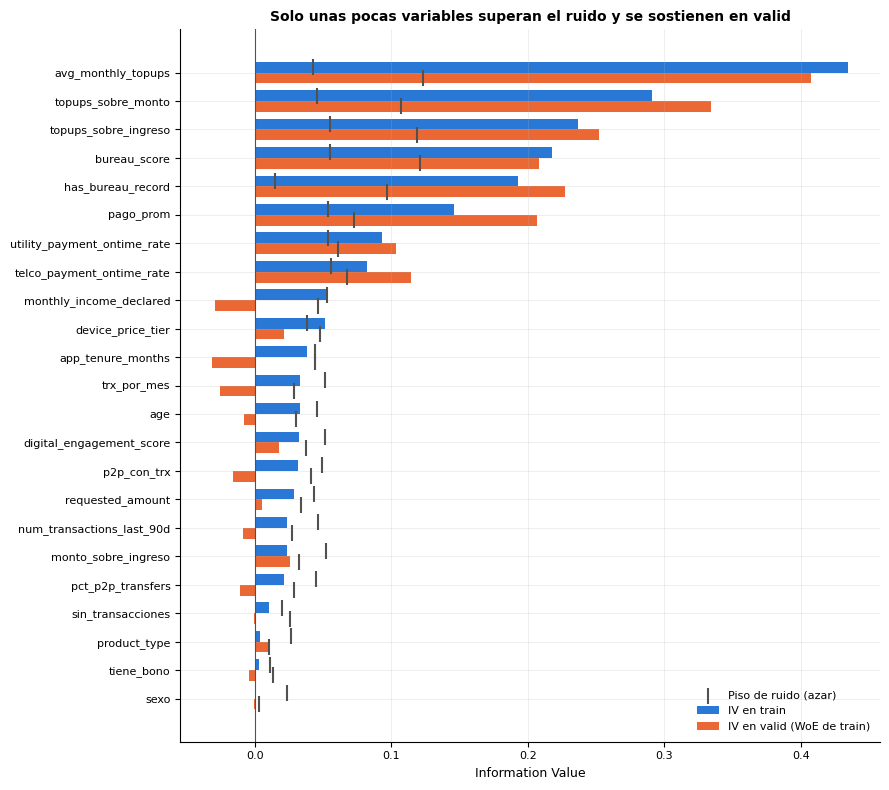

In [67]:
# IV de train y de valid contra el piso de ruido
orden = tabla_iv.sort_values("iv_train")
y_pos = np.arange(len(orden)); alto = 0.38
fig, ax = plt.subplots(figsize=(9, 8))
ax.barh(y_pos + alto / 2, orden["iv_train"], alto, color=COLORES["train"], label="IV en train")
ax.barh(y_pos - alto / 2, orden["iv_valid"], alto, color=COLORES["valid"], label="IV en valid (WoE de train)")
ax.scatter(orden["ruido_train"], y_pos + alto / 2, marker="|", s=120, color=COLORES["texto"], label="Piso de ruido (azar)", zorder=3)
ax.scatter(orden["ruido_valid"], y_pos - alto / 2, marker="|", s=120, color=COLORES["texto"], zorder=3)
ax.set_yticks(y_pos); ax.set_yticklabels(orden.index)
ax.axvline(0, color=COLORES["texto"], linewidth=0.8)
ax.set_xlabel("Information Value"); ax.set_title("Solo unas pocas variables superan el ruido y se sostienen en valid")
ax.legend(loc="lower right")
plt.tight_layout()

En la gráfica se ve la misma conclusión: solo las variables de recargas, buró y pago de servicios tienen IV claramente por encima de la marca de ruido (barra negra) **en train y en valid**. El resto está pegado o por debajo del ruido.

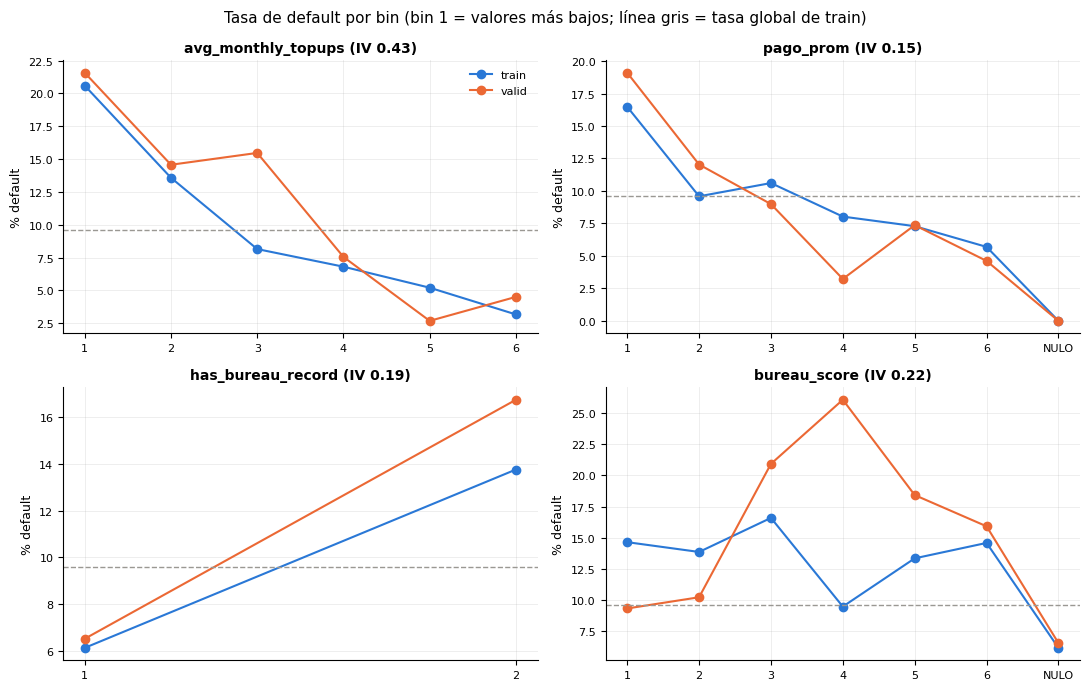

In [68]:
# Tasa de default por bin en train y valid: variables que entran
def tasas_por_bin(v):
    spec = fit_bins(train_w[v])
    bt, bv = apply_bins(train_w[v], spec), apply_bins(valid_w[v], spec)
    t = pd.DataFrame({"n_train": bt.value_counts(), "tasa_train": train_w[Y].groupby(bt, observed=True).mean() * 100,
                      "tasa_valid": valid_w[Y].groupby(bv, observed=True).mean() * 100})
    return t[t["n_train"] > 0]

def grafico_tasas(ax, v):
    t = tasas_por_bin(v)
    x = np.arange(len(t))
    ax.plot(x, t["tasa_train"], marker="o", color=COLORES["train"], linewidth=1.5, label="train")
    ax.plot(x, t["tasa_valid"], marker="o", color=COLORES["valid"], linewidth=1.5, label="valid")
    ax.axhline(train_w[Y].mean() * 100, color=COLORES["gris"], linestyle="--", linewidth=1)
    ax.set_xticks(x); ax.set_xticklabels([("NULO" if i == "NULO" else str(k + 1)) for k, i in enumerate(t.index)])
    ax.set_title(f"{v} (IV {tabla_iv.loc[v, 'iv_train']:.2f})"); ax.set_ylabel("% default")

fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, v in zip(axes.ravel(), ["avg_monthly_topups", "pago_prom", "has_bureau_record", "bureau_score"]):
    grafico_tasas(ax, v)
axes[0, 0].legend()
fig.suptitle("Tasa de default por bin (bin 1 = valores más bajos; línea gris = tasa global de train)", fontsize=11)
plt.tight_layout()

Las variables que entran tienen tasa de default ordenada y casi igual en train y valid. `avg_monthly_topups` baja de 20.6% en el primer bin a 3.2% en el último en train (21.6% y 4.5% en valid). `pago_prom` también baja, aunque con algo de ruido en valid (bin 4 con 3.2%, son pocos casos por bin). `has_bureau_record` tiene el efecto **contrario al esperado**: quienes tienen registro en buró defaultan más (13.8% vs 6.1% en train, 16.7% vs 6.5% en valid). Y `bureau_score` es una línea que sube y baja sin orden.

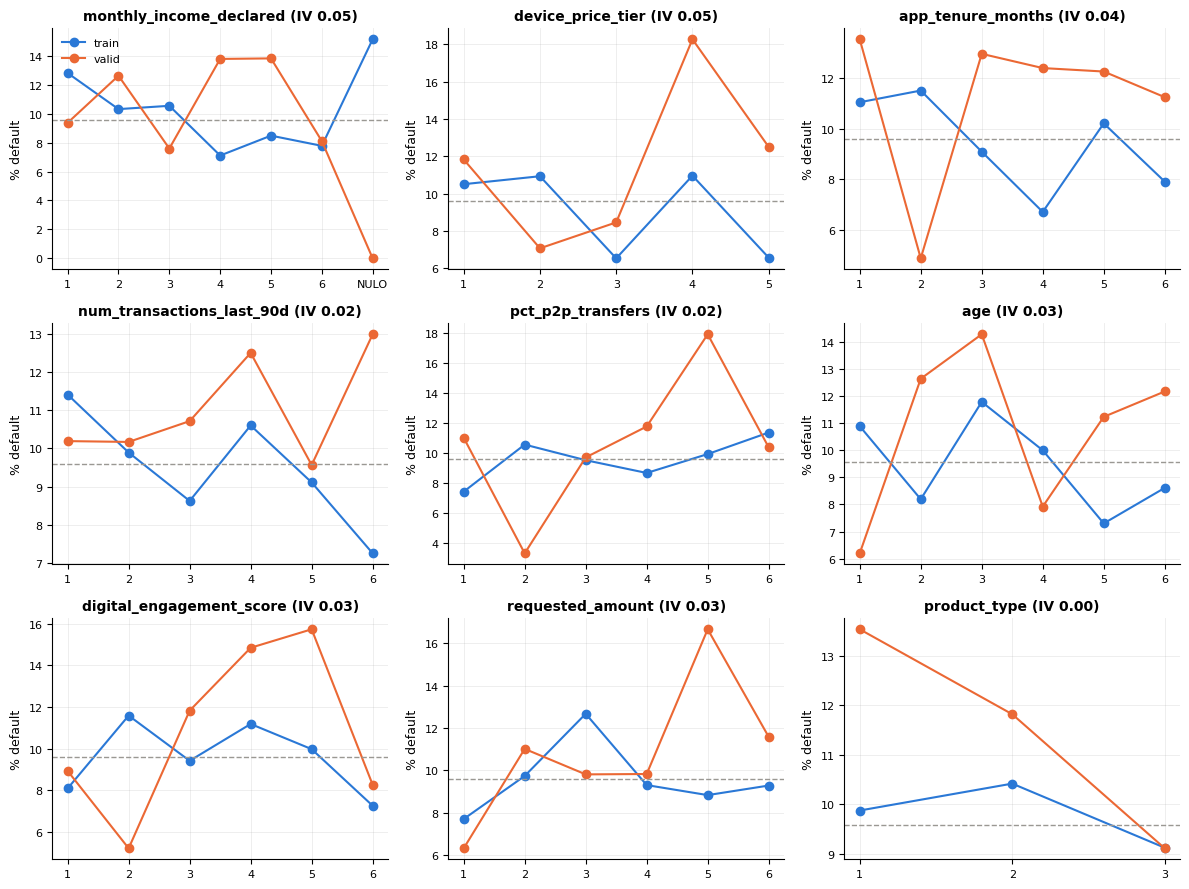

In [69]:
# Variables que NO entran: la tasa por bin no tiene orden o cambia entre train y valid
QUITADAS = ["monthly_income_declared", "device_price_tier", "app_tenure_months", "num_transactions_last_90d",
"pct_p2p_transfers", "age", "digital_engagement_score", "requested_amount", "product_type"]

fig, axes = plt.subplots(3, 3, figsize=(12, 9))
for ax, v in zip(axes.ravel(), QUITADAS):
    grafico_tasas(ax, v)
axes[0, 0].legend()
plt.tight_layout()

Las variables que se retiran no tienen ninguna forma consistente: las líneas de train y valid se cruzan, suben y bajan sin orden. Un modelo que las use estaría aprendiendo ruido de train.

## Estabilidad de las variables (PSI)

El PSI compara la distribución de cada variable en train contra valid y contra test. No usa la variable objetivo.

In [70]:
# PSI de cada variable: train contra valid y train contra test (no usa el objetivo)
VARS_PSI = ["avg_monthly_topups", "has_bureau_record", "bureau_score", "pago_prom", "utility_payment_ontime_rate",
            "telco_payment_ontime_rate", "monthly_income_declared", "device_price_tier", "app_tenure_months", "age",
            "digital_engagement_score", "requested_amount", "num_transactions_last_90d", "pct_p2p_transfers"]

tabla_psi = pd.DataFrame({"psi_valid": {v: psi(train_w[v], valid_w[v]) for v in VARS_PSI},
"psi_test": {v: psi(train_w[v], test_w[v]) for v in VARS_PSI}})
tabla_psi.sort_values("psi_test", ascending=False).round(3)

,psi_valid,psi_test
utility_payment_ontime_rate,0.094,0.773
pago_prom,0.116,0.452
telco_payment_ontime_rate,0.061,0.291
digital_engagement_score,0.026,0.020
app_tenure_months,0.024,0.018
bureau_score,0.019,0.017
pct_p2p_transfers,0.018,0.017
num_transactions_last_90d,0.024,0.016
age,0.030,0.016
monthly_income_declared,0.023,0.015


Casi todas las variables son estables (PSI < 0.03), incluidas `avg_monthly_topups` (0.014 en valid y 0.013 en test) y `has_bureau_record` (0.005 y 0.004). La excepción son las variables de **pago de servicios**: PSI de `utility_payment_ontime_rate` 0.094 en valid y **0.773** en test; `pago_prom` 0.116 y **0.452**; `telco_` 0.061 y **0.291**. Esto no es normal y hay que entenderlo antes de seguir.

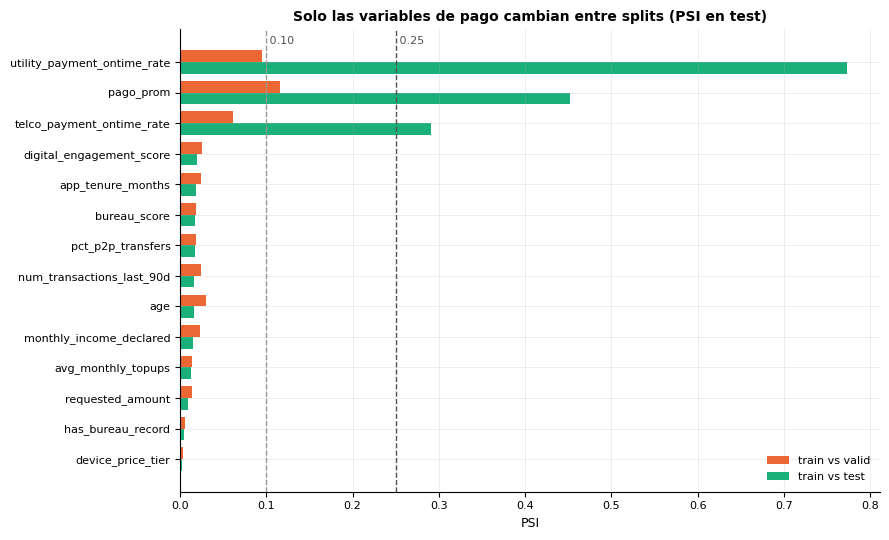

In [71]:
orden = tabla_psi.sort_values("psi_test")
y_pos = np.arange(len(orden)); alto = 0.38
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.barh(y_pos + alto / 2, orden["psi_valid"], alto, color=COLORES["valid"], label="train vs valid")
ax.barh(y_pos - alto / 2, orden["psi_test"], alto, color=COLORES["test"], label="train vs test")
ax.axvline(0.10, color=COLORES["gris"], linestyle="--", linewidth=1)
ax.axvline(0.25, color=COLORES["texto"], linestyle="--", linewidth=1)
ax.text(0.10, len(orden) - 0.4, " 0.10", fontsize=8, color=COLORES["texto"])
ax.text(0.25, len(orden) - 0.4, " 0.25", fontsize=8, color=COLORES["texto"])
ax.set_yticks(y_pos); ax.set_yticklabels(orden.index)
ax.set_xlabel("PSI"); ax.set_title("Solo las variables de pago cambian entre splits (PSI en test)")
ax.legend(loc="lower right")
plt.tight_layout()

In [72]:
# Estabilidad en el tiempo de las variables finalistas: promedio por mes de solicitud
trim = pd.concat([train_w, valid_w, test_w]).assign(trimestre=lambda d: pd.to_datetime(d["application_date"]).dt.to_period("M").astype(str))
estab = trim.groupby("trimestre").agg(n=("application_id", "size"), default_pct=(Y, lambda s: s.mean() * 100),
topups_mediana=("avg_monthly_topups", "median"),
con_bureau_pct=("has_bureau_record", lambda s: s.mean() * 100),
pago_prom=("pago_prom", "mean")).round(2)
estab

,n,default_pct,topups_mediana,con_bureau_pct,pago_prom
trimestre,,,,,
2024-01,339,9.73,42154.0,40.71,0.75
2024-02,332,9.94,40241.0,43.37,0.74
2024-03,326,9.82,46031.0,48.47,0.75
2024-04,348,9.77,38483.0,48.56,0.75
2024-05,327,9.17,38792.0,44.65,0.75
2024-06,356,11.80,41304.5,47.19,0.75
2024-07,292,8.22,41238.5,43.84,0.75
2024-08,331,7.85,45779.0,45.02,0.75
2024-09,293,8.87,43651.0,40.27,0.76


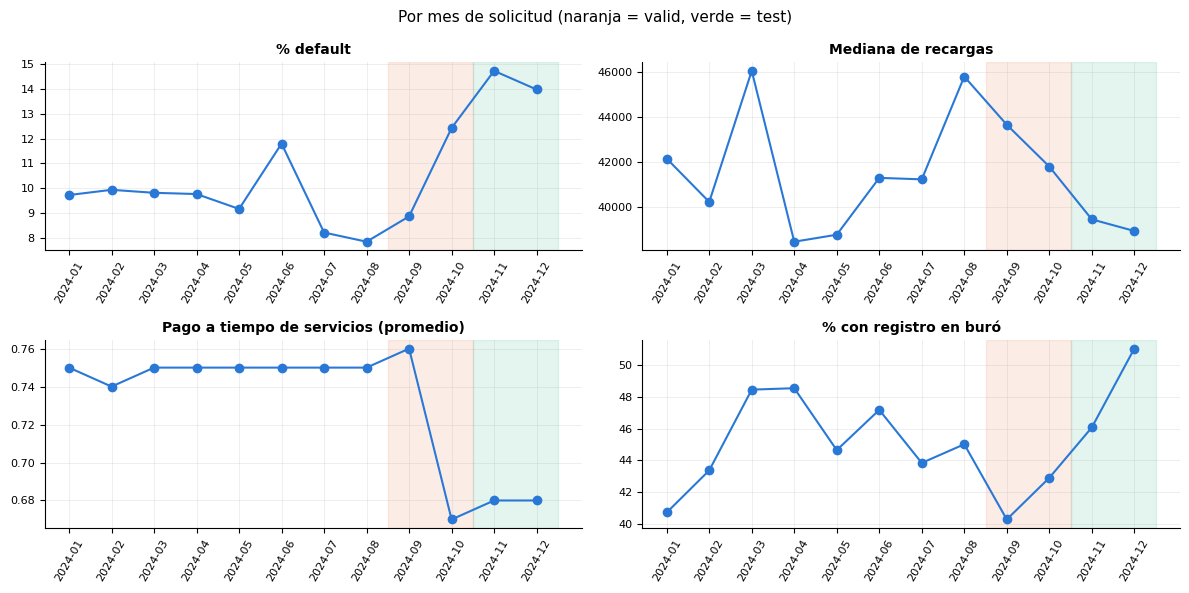

In [73]:
fig, axes = plt.subplots(2, 2, figsize=(12, 6))
for ax, (col, titulo) in zip(axes.ravel(), [("default_pct", "% default"), ("topups_mediana", "Mediana de recargas"),
    ("pago_prom", "Pago a tiempo de servicios (promedio)"), ("con_bureau_pct", "% con registro en buró")]):
    ax.plot(estab.index, estab[col], marker="o", color=COLORES["train"], linewidth=1.5)
    ax.axvspan(7.5, 9.5, color=COLORES["valid"], alpha=0.12)   # valid: sep-oct
    ax.axvspan(9.5, 11.5, color=COLORES["test"], alpha=0.12)   # test: nov-dic
    ax.set_title(titulo); ax.tick_params(axis="x", rotation=60)
fig.suptitle("Por mes de solicitud (naranja = valid, verde = test)", fontsize=11)
plt.tight_layout()

La evolución mensual lo explica: el promedio de pago a tiempo es 0.75 estable de enero a septiembre de 2024 y **cae de golpe a 0.67 en octubre** (0.68 en nov y dic). No es un cambio gradual, es un escalón. Al mismo tiempo el default oscila entre 7.9% y 11.8% de enero a septiembre y pasa a 12.4% en octubre, 14.7% en noviembre y 14.0% en diciembre. La mediana de recargas baja un poco (de 43.651 en septiembre a 38.957 en diciembre) y el % con buró sube (de 40.3% a 51.1%). Es decir, la población que llega a fin de año tiene peor comportamiento de pago y más defaults.

### Cambio de octubre de 2024

Lo importante es saber si las variables de pago **siguen ordenando el riesgo** después del cambio, o si el cambio las dañó. Lo medimos con el AUC de `pago_prom` en cada split. Aquí se usa el objetivo de test solo como diagnóstico para el informe; no se cambia ninguna decisión.

In [74]:
# El cambio de octubre 2024: ¿las variables de pago siguen ordenando el riesgo dentro de cada split? (AUC de pago_prom)
for nombre, df in [("train", train_w), ("valid", valid_w), ("test", test_w)]:
    d = df.dropna(subset=["pago_prom"])
    print(f"{nombre}: media pago_prom={d['pago_prom'].mean():.3f} | default={df[Y].mean() * 100:.1f}% | AUC pago_prom={auc_ks(-d['pago_prom'].values, d[Y].values)[0]:.3f}")

train: media pago_prom=0.748 | default=9.6% | AUC pago_prom=0.605
valid: media pago_prom=0.711 | default=10.8% | AUC pago_prom=0.660
test: media pago_prom=0.683 | default=14.4% | AUC pago_prom=0.580


`pago_prom` sigue ordenando el riesgo en los tres splits (AUC 0.605 en train, 0.660 en valid y 0.580 en test), aunque en test baja. La media de pago cae de 0.748 a 0.683 y el default sube de 9.6% a 14.4%.

In [75]:
# Misma pregunta para el default según bins de train de pago_prom: en test la gente cae en bins más bajos
spec_pago = fit_bins(train_w["pago_prom"])
comp = pd.DataFrame({n: apply_bins(d["pago_prom"], spec_pago).value_counts(normalize=True) * 100 for n, d in [("train", train_w), ("valid", valid_w), ("test", test_w)]}).round(1)
comp

,train,valid,test
pago_prom,,,
"(-inf, 0.648]",16.7,28.2,34.3
"(0.648, 0.708]",16.5,17.1,22.5
"(0.708, 0.757]",16.7,14.1,17.0
"(0.757, 0.801]",16.4,14.7,12.2
"(0.801, 0.854]",16.6,15.1,10.5
"(0.854, inf]",16.6,10.3,3.2
NULO,0.5,0.5,0.3


Con los bins de train, en test el 34.3% de los clientes cae en el bin de peor pago (esperado: 16.7%) y solo el 3.2% en el mejor (esperado 16.6%). Es un corrimiento real de la población hacia más riesgo, no un error de datos: los valores siguen en el rango y la mayoría de la gente se mueve junto. Consecuencia para el modelo: el score va a subir en test (más clientes de PD alta) y la PD media va a quedar por debajo de la real, lo cual se verifica en la sección final.

## Clientes sin buró (thin file)

El 55% de los clientes no tiene registro en buró, y esa es justamente la población objetivo del piloto. Hay que ver (1) cuánto defaultan, (2) si las variables alternativas (recargas, pago de servicios) los ordenan, y (3) qué pasa con `bureau_score` entre quienes sí lo tienen.

In [76]:
# Cuántos clientes no tienen buró y cuánto defaultan
resumen_buro = pd.concat([d.assign(split=n) for d, n in [(train_w, "train"), (valid_w, "valid"), (test_w, "test")]]) \
                 .groupby(["split", "has_bureau_record"])[Y].agg(n="size", eventos="sum", tasa="mean").round(3)
resumen_buro

n  eventos   tasa
split has_bureau_record                      
test  0                   333       23  0.069
      1                   315       70  0.222
train 0                  1451       89  0.061
      1                  1200      165  0.138
valid 0                   368       24  0.065
      1                   263       44  0.167

Resultado contraintuitivo: los clientes **sin buró defaultan menos** (6.1% train, 6.5% valid, 6.9% test) que los clientes con buró (13.8%, 16.7% y 22.2%). Una hipótesis (no verificable con estos datos) es de selección: quien ya tiene historial en buró puede estar más endeudado. No podemos probarla; lo que sí podemos decir es que `has_bureau_record` es un predictor estable (IV 0.193 en train y 0.227 en valid) pero con signo contrario al que supondría el negocio. Por eso no se debe usar para "premiar" a quien tiene buró sin entender por qué.

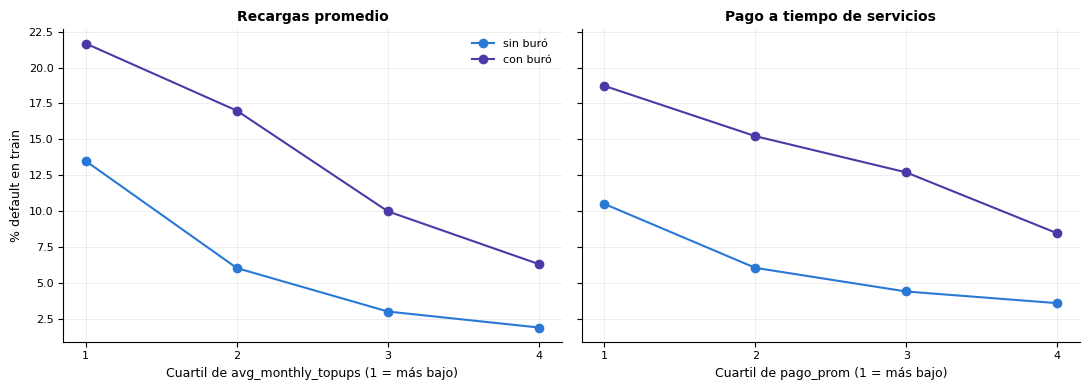

In [77]:
# Dentro del segmento SIN buró: ¿las recargas y el pago de servicios siguen ordenando el riesgo?
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, (v, titulo) in zip(axes, [("avg_monthly_topups", "Recargas promedio"), ("pago_prom", "Pago a tiempo de servicios")]):
    for tiene, color, etiqueta in [(0, COLORES["train"], "sin buró"), (1, COLORES["violeta"], "con buró")]:
        seg = train_w[train_w["has_bureau_record"] == tiene]
        cortes = pd.qcut(seg[v], 4, labels=False, duplicates="drop")
        tasas = seg.groupby(cortes)[Y].mean() * 100
        ax.plot(tasas.index + 1, tasas.values, marker="o", color=color, linewidth=1.5, label=etiqueta)
    ax.set_xticks([1, 2, 3, 4]); ax.set_xlabel(f"Cuartil de {v} (1 = más bajo)"); ax.set_title(titulo)
axes[0].set_ylabel("% default en train"); axes[0].legend()
plt.tight_layout()

Dentro del segmento sin buró, las variables alternativas ordenan bien el riesgo: la tasa de default baja de 13.5% a 1.9% a medida que suben las recargas. Esa es la señal que permite evaluar a un cliente sin historial.

In [78]:
# AUC dentro de cada segmento (valid) del score del modelo base. Primero el score solo con recargas
def auc_segmento(df, col):
    return auc_ks(-df[col].values, df[Y].values)[0]

for tiene, nombre in [(0, "sin buró"), (1, "con buró")]:
    seg = valid_w[valid_w["has_bureau_record"] == tiene]
    print(f"{nombre:9s} n={len(seg):4d} eventos={seg[Y].sum():3d} | AUC recargas={auc_segmento(seg, 'avg_monthly_topups'):.3f} | AUC pago_prom={auc_segmento(seg.dropna(subset=['pago_prom']), 'pago_prom'):.3f}")

sin buró  n= 368 eventos= 24 | AUC recargas=0.680 | AUC pago_prom=0.734
con buró  n= 263 eventos= 44 | AUC recargas=0.724 | AUC pago_prom=0.635


En valid, el AUC dentro de cada segmento es de 0.680 con recargas y 0.734 con el pago de servicios para clientes sin buró, y 0.724 y 0.635 para los que tienen buró. Un solo modelo funciona para los dos segmentos porque las variables alternativas ordenan en ambos.

In [79]:
# bureau_score entre quienes SÍ tienen buró: ¿ordena el riesgo? (AUC con IC95% por bootstrap)
def auc_bootstrap(score, y, B=1000):
    score, y = np.asarray(score, float), np.asarray(y)
    r = np.random.default_rng(SEED)
    aucs = []
    for _ in range(B):
        i = r.integers(0, len(y), len(y))
        aucs.append(auc_ks(score[i], y[i])[0])
    return np.percentile(aucs, [2.5, 97.5])

for nombre, df in [("train", train_w), ("valid", valid_w)]:
    seg = df[df["has_bureau_record"] == 1]
    a = auc_ks(-seg["bureau_score"].values, seg[Y].values)[0]
    lo, hi = auc_bootstrap(-seg["bureau_score"].values, seg[Y].values)
    print(f"{nombre}: n={len(seg)} eventos={seg[Y].sum()} AUC={a:.3f} IC95%=({lo:.3f}, {hi:.3f})")

train: n=1200 eventos=165 AUC=0.509 IC95%=(0.461, 0.557)
valid: n=263 eventos=44 AUC=0.422 IC95%=(0.345, 0.507)


`bureau_score` entre quienes lo tienen **no discrimina**: AUC 0.509 en train (IC95% 0.461 a 0.557) y 0.422 en valid (IC95% 0.345 a 0.507). Un AUC de 0.5 es el azar; un AUC de 0.42 en valid con intervalo que incluye 0.5 es también indistinguible del azar con 44 eventos. Su IV de 0.217 sale entonces de la diferencia entre tener y no tener buró, no de cuánto vale el puntaje.

C:\Users\moren\AppData\Local\Temp\ipykernel_23284\2036880721.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tasas = seg.groupby(pd.qcut(seg["bureau_score"], 10))[Y].mean() * 100


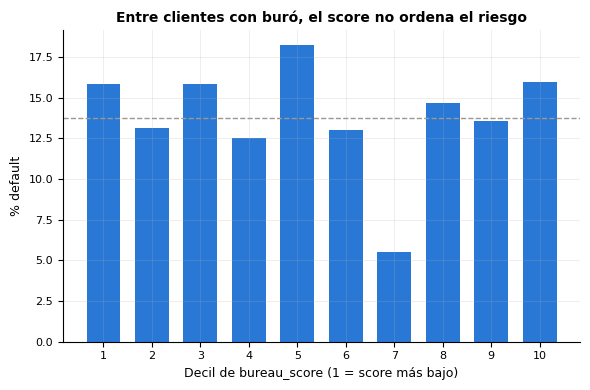

In [80]:
# bureau_score contra default (train, solo con buró): sin tendencia clara
seg = train_w[train_w["has_bureau_record"] == 1]
fig, ax = plt.subplots(figsize=(6, 4))
tasas = seg.groupby(pd.qcut(seg["bureau_score"], 10))[Y].mean() * 100
ax.bar(range(1, 11), tasas.values, color=COLORES["train"], width=0.7)
ax.axhline(seg[Y].mean() * 100, color=COLORES["gris"], linestyle="--", linewidth=1)
ax.set_xticks(range(1, 11)); ax.set_xlabel("Decil de bureau_score (1 = score más bajo)"); ax.set_ylabel("% default")
ax.set_title("Entre clientes con buró, el score no ordena el riesgo")
plt.tight_layout()

La tasa de default no tiene tendencia a lo largo de los deciles del score: va de 5.5% a 18.3% sin orden. Decisión: `bureau_score` se prueba en un modelo aparte (modelo B) y se compara con valid.

## Redundancia entre variables

Antes de elegir el conjunto final revisamos la correlación de Spearman y el VIF para no incluir variables que digan lo mismo.

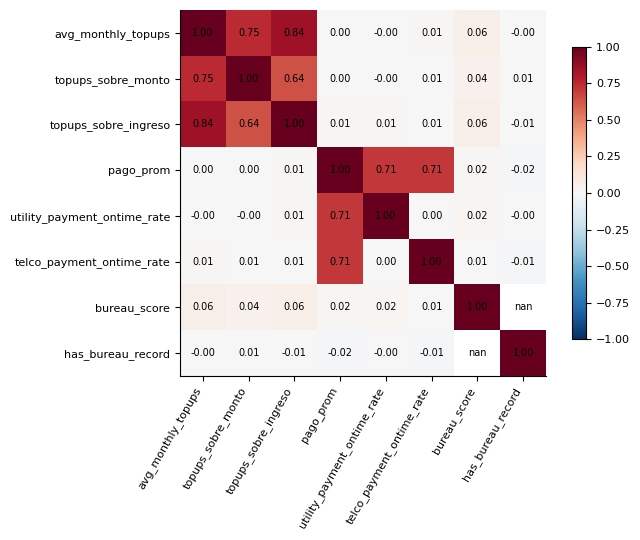

In [81]:
# Correlación de Spearman entre las variables candidatas que pasaron el filtro de IV (train)
CAND_FINAL = ["avg_monthly_topups", "topups_sobre_monto", "topups_sobre_ingreso", "pago_prom", "utility_payment_ontime_rate",
              "telco_payment_ontime_rate", "bureau_score", "has_bureau_record"]
corr = train_w[CAND_FINAL].corr(method="spearman")

fig, ax = plt.subplots(figsize=(7, 5.5))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=60, ha="right")
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.columns)
ax.grid(False)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=7)
plt.colorbar(im, shrink=0.8)
plt.tight_layout()

La correlación entre `avg_monthly_topups` y `topups_sobre_monto` es alta porque la segunda es la primera dividida por el monto solicitado, y el monto no aporta (IV fuera de ruido). Se deja la variable original (más simple y explicable). `pago_prom` es un promedio de los dos componentes y los resume.

In [82]:
# VIF (qué tan explicada está cada variable por las demás) del conjunto final propuesto
def vif(df, cols):
    X = df[cols].fillna(df[cols].median())
    out = {}
    for c in cols:
        otras = [o for o in cols if o != c]
        A = np.column_stack([np.ones(len(X)), X[otras].values])
        beta, *_ = np.linalg.lstsq(A, X[c].values, rcond=None)
        resid = X[c].values - A @ beta
        r2 = 1 - resid.var() / X[c].values.var()
        out[c] = 1 / (1 - r2)
    return pd.Series(out).round(2)

print("Conjunto final (3 variables):")
print(vif(train_w, ["avg_monthly_topups", "pago_prom", "has_bureau_record"]).to_string())
print("\nSi se agrega topups_sobre_monto:")
print(vif(train_w, ["avg_monthly_topups", "topups_sobre_monto", "pago_prom", "has_bureau_record"]).to_string())
print("\nSi se agregan las 10 variables quitadas:")
print(vif(train_w, ["avg_monthly_topups", "pago_prom", "has_bureau_record", "age", "monthly_income_declared", "app_tenure_months",
                    "num_transactions_last_90d", "pct_p2p_transfers", "digital_engagement_score", "requested_amount", "device_price_tier"]).to_string())

Conjunto final (3 variables):
avg_monthly_topups    1.0
pago_prom             1.0
has_bureau_record     1.0

Si se agrega topups_sobre_monto:
avg_monthly_topups    1.01
topups_sobre_monto    1.01
pago_prom             1.00
has_bureau_record     1.00

Si se agregan las 10 variables quitadas:
avg_monthly_topups           1.00
pago_prom                    1.00
has_bureau_record            1.01
age                          1.00
monthly_income_declared      1.00
app_tenure_months            7.62
num_transactions_last_90d    7.61
pct_p2p_transfers            1.00
digital_engagement_score     1.01
requested_amount             1.00
device_price_tier            1.01


El VIF del conjunto final es 1.0 en las tres variables: no hay redundancia. Con las 10 variables retiradas, `app_tenure_months` y `num_transactions_last_90d` llegan a VIF 7.6 (están correlacionadas 0.90 entre sí), otro motivo para no incluirlas: las dos juntas hacen inestables los coeficientes y ninguna aporta señal.

In [83]:
# app_tenure_months y num_transactions_last_90d: la correlación explica por qué se mueven juntas
print("Spearman tenure vs transacciones:", round(train_w[["app_tenure_months", "num_transactions_last_90d"]].corr(method="spearman").iloc[0, 1], 3))
print("Spearman recargas vs ingreso declarado:", round(train_w[["avg_monthly_topups", "monthly_income_declared"]].corr(method="spearman").iloc[0, 1], 3))

Spearman tenure vs transacciones: 0.901
Spearman recargas vs ingreso declarado: 0.014


La correlación de 0.90 entre antigüedad y transacciones tiene sentido: quien lleva más meses en la app ha tenido más tiempo para transar. Las recargas casi no se relacionan con el ingreso declarado (Spearman 0.014), por eso `topups_sobre_ingreso` no ayuda: el ingreso declarado es una variable muy ruidosa.

## Selección final de variables

Con todo lo anterior el conjunto base queda en **tres variables**:

1. `avg_monthly_topups`: la más fuerte (IV 0.435 / 0.407, AUC en valid 0.686). Mide capacidad de flujo digital.
2. `pago_prom`: promedio de pago a tiempo de servicios (IV 0.146 / 0.207).
3. `has_bureau_record`: señala si el cliente tiene historial en buró. Con sentido contrario al esperado, pero estable.

`bureau_score` queda como experimento (modelo B) y las 10 variables retiradas se miden en el modelo C para demostrar con números que retirarlas fue correcto.

In [84]:
BASE = ["avg_monthly_topups", "has_bureau_record", "pago_prom"]
RETIRADAS = ["age", "monthly_income_declared", "app_tenure_months", "num_transactions_last_90d", "pct_p2p_transfers",
             "digital_engagement_score", "requested_amount", "device_price_tier", "product_type", "sexo"]

seleccion = tabla_iv.loc[BASE + ["bureau_score", "topups_sobre_monto"], ["iv_train", "iv_valid", "auc_valid", "ks_valid", "decision"]].round(3)
seleccion

,iv_train,iv_valid,auc_valid,ks_valid,decision
variable,,,,,
avg_monthly_topups,0.435,0.407,0.686,0.321,ENTRA
has_bureau_record,0.193,0.227,0.629,0.258,ENTRA
pago_prom,0.146,0.207,0.652,0.244,ENTRA
bureau_score,0.217,0.208,0.617,0.258,REVISAR: patron por bin inestable
topups_sobre_monto,0.291,0.334,0.682,0.279,ENTRA


## Modelos

Se entrenan en train y se comparan en valid:

* **Regresión logística sobre WoE** (scorecard), modelos A, B, C y D. Cada variable se reemplaza por el WoE de su bin; sin regularización porque hay muy pocas variables.
* **Gradient boosting** (`HistGradientBoostingClassifier`, árboles de profundidad 3), modelos E y F, como retador no lineal.

Experimentos: A = base (3 variables); B = A + `bureau_score` (el nulo vale 0 por ser neutro); C = A + las 10 variables retiradas; D = sin `pago_prom` (por si el corrimiento de octubre lo hace riesgoso); E y F = lo mismo en boosting.

In [85]:
# Matrices de entrenamiento. Regresión logística: cada variable se reemplaza por el WoE de su bin (bins y WoE calculados en train)
def woe_matrix(cols, nulo_neutro=()):
    X = {"train": pd.DataFrame(index=train_w.index), "valid": pd.DataFrame(index=valid_w.index), "test": pd.DataFrame(index=test_w.index)}
    for c in cols:
        spec = fit_bins(train_w[c])
        woe = woe_map(apply_bins(train_w[c], spec), ytr)
        if c in nulo_neutro:
            woe["NULO"] = 0.0          # sin dato = efecto neutro (esa información ya la lleva has_bureau_record)
        for nombre, df in [("train", train_w), ("valid", valid_w), ("test", test_w)]:
            X[nombre][c] = apply_bins(df[c], spec).astype(str).map(woe.to_dict()).fillna(0).values
    return X

def logit(cols, nulo_neutro=(), **kw):
    X = woe_matrix(cols, nulo_neutro)
    m = LogisticRegression(C=np.inf, max_iter=2000, **kw).fit(X["train"], ytr)
    return {"modelo": m, "X": X, "cols": cols,
            "p": {k: m.predict_proba(X[k])[:, 1] for k in X}}

# Gradient boosting: recibe las variables sin transformar (maneja nulos solo)
def gbm(cols):
    X = {n: pd.get_dummies(d[cols], columns=[c for c in cols if c in ("sexo", "product_type")], dtype=int)
         for n, d in [("train", train_w), ("valid", valid_w), ("test", test_w)]}
    m = HistGradientBoostingClassifier(max_depth=3, learning_rate=0.05, max_iter=200, min_samples_leaf=40,
                                       l2_regularization=1.0, early_stopping=False, random_state=0).fit(X["train"], ytr)
    return {"modelo": m, "X": X, "cols": cols, "p": {k: m.predict_proba(X[k])[:, 1] for k in X}}

In [86]:
# Los cuatro experimentos principales (en train; se evalúan en valid)
modelos = {
    "A  Logit: base (3 variables)":              logit(BASE),
    "B  Logit: base + bureau_score":             logit(BASE + ["bureau_score"], nulo_neutro=("bureau_score",)),
    "C  Logit: base + 10 variables retiradas":   logit(BASE + RETIRADAS),
    "D  Logit: sin pago_prom (solo recargas y buró)": logit(["avg_monthly_topups", "has_bureau_record"]),
    "E  GBM: base":                              gbm(BASE),
    "F  GBM: base + 10 variables retiradas":     gbm(BASE + RETIRADAS),
}
for nombre, m in modelos.items():
    print(nombre, "->", len(m["cols"]), "variables")

A  Logit: base (3 variables) -> 3 variables
B  Logit: base + bureau_score -> 4 variables
C  Logit: base + 10 variables retiradas -> 13 variables
D  Logit: sin pago_prom (solo recargas y buró) -> 2 variables
E  GBM: base -> 3 variables
F  GBM: base + 10 variables retiradas -> 13 variables


In [87]:
# Métricas: AUC, KS, PR-AUC (average precision), Brier y calibracion global. IC95% por bootstrap contra el modelo A
def bootstrap_dif(p_a, p_b, y, B=1000):
    r = np.random.default_rng(SEED)
    difs = []
    for _ in range(B):
        i = r.integers(0, len(y), len(y))
        difs.append(auc_ks(p_b[i], y[i])[0] - auc_ks(p_a[i], y[i])[0])
    return np.percentile(difs, [2.5, 97.5])

p_ref = modelos["A  Logit: base (3 variables)"]["p"]["valid"]
filas = []
for nombre, m in modelos.items():
    auc_t, ks_t = auc_ks(m["p"]["train"], ytr)
    auc_v, ks_v = auc_ks(m["p"]["valid"], yva)
    lo, hi = bootstrap_dif(p_ref, m["p"]["valid"], yva)
    filas.append({"modelo": nombre, "auc_train": auc_t, "auc_valid": auc_v, "ks_train": ks_t, "ks_valid": ks_v,
    "pr_auc_valid": average_precision_score(yva, m["p"]["valid"]),
    "dif_auc_vs_A": auc_v - auc_ks(p_ref, yva)[0], "ic95_dif": f"({lo:+.3f}, {hi:+.3f})",
    "pred_media": m["p"]["valid"].mean(), "tasa_real": yva.mean()})
tabla_modelos = pd.DataFrame(filas).set_index("modelo")
tabla_modelos.round(3)

,auc_train,auc_valid,ks_train,ks_valid,pr_auc_valid,dif_auc_vs_A,ic95_dif,pred_media,tasa_real
modelo,,,,,,,,,
A Logit: base (3 variables),0.750,0.781,0.386,0.461,0.312,0.000,"(+0.000, +0.000)",0.099,0.108
B Logit: base + bureau_score,0.751,0.771,0.395,0.439,0.325,-0.010,"(-0.022, +0.001)",0.098,0.108
C Logit: base + 10 variables retiradas,0.780,0.729,0.424,0.398,0.297,-0.051,"(-0.091, -0.017)",0.097,0.108
D Logit: sin pago_prom (solo recargas y buró),0.723,0.729,0.336,0.406,0.233,-0.052,"(-0.084, -0.024)",0.091,0.108
E GBM: base,0.836,0.789,0.528,0.487,0.310,0.008,"(-0.027, +0.045)",0.109,0.108
F GBM: base + 10 variables retiradas,0.907,0.747,0.662,0.388,0.267,-0.034,"(-0.080, +0.014)",0.100,0.108


Lectura (valid, 631 créditos y 68 eventos):

* **A (logística, 3 variables)**: AUC 0.781, KS 0.461, PR-AUC 0.312. La diferencia entre train (AUC 0.750) y valid es mínima, no hay sobreajuste. La PD media predicha (9.9%) es cercana a la real (10.8%).
* **B (+ `bureau_score`)**: AUC 0.771, diferencia -0.010 con IC95% (-0.022, +0.001). No mejora y empeora un poco. Se descarta.
* **C (+ 10 variables retiradas)**: AUC 0.729, -0.051 con IC (-0.091, -0.017), la única diferencia claramente negativa. En train sube a 0.780 (aprende ruido) y en valid cae. Confirma que retirarlas fue correcto.
* **D (sin `pago_prom`)**: AUC 0.729, -0.052, IC (-0.084, -0.024). `pago_prom` aporta de verdad, no se retira a pesar del corrimiento.
* **E (boosting, 3 variables)**: AUC 0.784, diferencia +0.003 con IC (-0.032, +0.039): empata con A, pero en train llega a AUC 0.837 y KS 0.524, o sea memoriza más. **F** (boosting con 13 variables) llega a 0.906 en train y baja a 0.745 en valid.

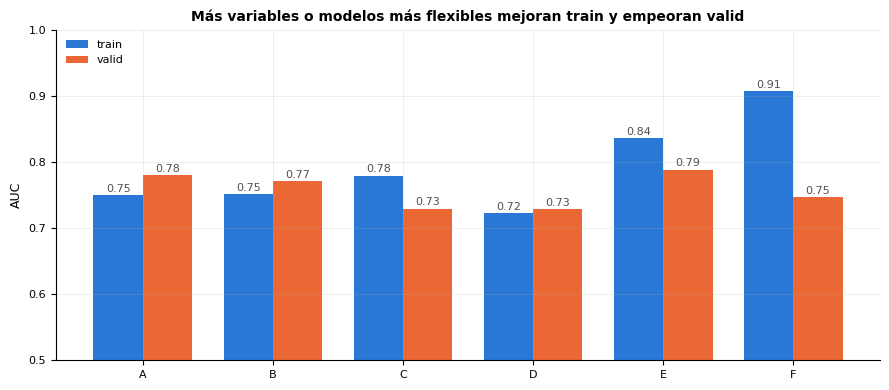

In [88]:
# AUC en train vs valid: la brecha muestra cuánto se sobreajusta cada modelo
nombres = [n[0] for n in tabla_modelos.index]
x = np.arange(len(nombres)); ancho = 0.38
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(x - ancho / 2, tabla_modelos["auc_train"], ancho, color=COLORES["train"], label="train")
ax.bar(x + ancho / 2, tabla_modelos["auc_valid"], ancho, color=COLORES["valid"], label="valid")
for i, (a, b) in enumerate(zip(tabla_modelos["auc_train"], tabla_modelos["auc_valid"])):
    ax.text(i - ancho / 2, a + 0.005, f"{a:.2f}", ha="center", fontsize=8, color=COLORES["texto"])
    ax.text(i + ancho / 2, b + 0.005, f"{b:.2f}", ha="center", fontsize=8, color=COLORES["texto"])
ax.set_xticks(x); ax.set_xticklabels(nombres); ax.set_ylim(0.5, 1.0)
ax.set_ylabel("AUC"); ax.set_title("Más variables o modelos más flexibles mejoran train y empeoran valid")
ax.legend(loc="upper left")
plt.tight_layout()

La gráfica resume lo anterior: la brecha train-valid es pequeña en A y B y gigante en F (0.91 contra 0.75). Con 254 eventos, un modelo flexible aprende el ruido de train.

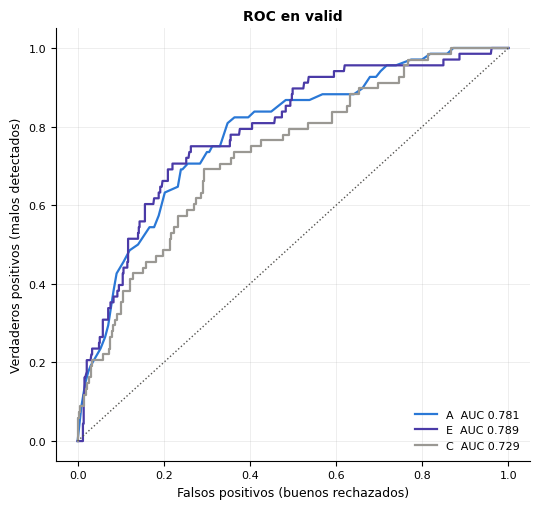

In [89]:
# Curvas ROC en valid
fig, ax = plt.subplots(figsize=(5.5, 5.2))
for nombre, color in [("A  Logit: base (3 variables)", COLORES["train"]), ("E  GBM: base", COLORES["violeta"]),
                      ("C  Logit: base + 10 variables retiradas", COLORES["gris"])]:
    fpr, tpr, _ = roc_curve(yva, modelos[nombre]["p"]["valid"])
    ax.plot(fpr, tpr, color=color, linewidth=1.6, label=f"{nombre[0]}  AUC {tabla_modelos.loc[nombre, 'auc_valid']:.3f}")
ax.plot([0, 1], [0, 1], color=COLORES["texto"], linestyle=":", linewidth=1)
ax.set_xlabel("Falsos positivos (buenos rechazados)"); ax.set_ylabel("Verdaderos positivos (malos detectados)")
ax.set_title("ROC en valid"); ax.legend(loc="lower right")
plt.tight_layout()

Las curvas de A y E (boosting) prácticamente se superponen. El modelo con las 10 variables retiradas (C) queda por debajo en casi todo el recorrido.

In [90]:
# Coeficientes del modelo A: sobre WoE (= ln buenos/malos) se espera signo negativo
mA = modelos["A  Logit: base (3 variables)"]["modelo"]
coef_A = pd.Series(mA.coef_[0], index=BASE)
print(coef_A.round(3).to_string()); print("Intercepto:", round(mA.intercept_[0], 3))
print("\nTasa media predicha en valid:", round(modelos["A  Logit: base (3 variables)"]["p"]["valid"].mean(), 3), "| tasa real:", round(yva.mean(), 3))

avg_monthly_topups   -1.045
has_bureau_record    -1.055
pago_prom            -1.038
Intercepto: -2.251

Tasa media predicha en valid: 0.099 | tasa real: 0.108


Los tres coeficientes son negativos y cercanos a -1 (-1.045, -1.055 y -1.038). Como el WoE ya es ln(buenos/malos), un coeficiente de -1 significa que el WoE entra al modelo casi tal cual: el scorecard queda coherente y cada variable pesa parecido. No hay signos invertidos, que sería el síntoma de multicolinealidad.

In [91]:
# Contribución de cada variable al AUC de valid: AUC del modelo con solo esa variable y quitando una a la vez
solo = {c: auc_ks(logit([c])["p"]["valid"], yva)[0] for c in BASE}
sin = {c: auc_ks(logit([o for o in BASE if o != c])["p"]["valid"], yva)[0] for c in BASE}
aporte = pd.DataFrame({"auc_solo_esa": solo, "auc_sin_ella": sin}).round(3)
aporte

,auc_solo_esa,auc_sin_ella
avg_monthly_topups,0.686,0.712
has_bureau_record,0.629,0.747
pago_prom,0.652,0.729


Cada variable aporta: quitar `has_bureau_record` baja el AUC en valid de 0.781 a 0.747, quitar `pago_prom` a 0.729 y quitar las recargas a 0.712.

## Desbalance de clases

La tasa de default es 9.6% en train (254 eventos de 2.651), un desbalance moderado. Revisamos dos cosas: si ajustar pesos cambia algo, y qué pasaría si la tasa real fuera mucho más baja (3%) como suele pasar en carteras de producción.

In [92]:
# Desbalance. Tasa de eventos real: 9.6% en train. Primero, ¿class_weight="balanced" cambia el ordenamiento o solo la calibración?
m_bal = logit(BASE, class_weight="balanced")
for nombre, m in [("sin ajuste", modelos["A  Logit: base (3 variables)"]), ("class_weight=balanced", m_bal)]:
    a, k = auc_ks(m["p"]["valid"], yva)
    print(f"{nombre:22s} AUC={a:.3f} KS={k:.3f} PR-AUC={average_precision_score(yva, m['p']['valid']):.3f} | PD media predicha={m['p']['valid'].mean():.3f} (real {yva.mean():.3f})")

sin ajuste             AUC=0.781 KS=0.461 PR-AUC=0.312 | PD media predicha=0.099 (real 0.108)
class_weight=balanced  AUC=0.782 KS=0.461 PR-AUC=0.312 | PD media predicha=0.437 (real 0.108)


`class_weight="balanced"` **no cambia el ordenamiento** (AUC 0.782 y KS 0.461, igual que sin ajuste) pero daña la calibración: la PD media predicha pasa de 9.9% a 43.7% cuando la tasa real es 10.8%. Como el objetivo del modelo es estimar una probabilidad de default, no se usan pesos.

In [93]:
# Simulación: ¿qué pasa si la tasa de default fuera 3% en lugar de ~10%? Se descartan eventos al azar (train y valid) y se repite 20 veces
def submuestra(df, y, objetivo_tasa, r):
    malos, buenos = np.where(y == 1)[0], np.where(y == 0)[0]
    n_malos = int(objetivo_tasa / (1 - objetivo_tasa) * len(buenos))
    return np.sort(np.concatenate([buenos, r.choice(malos, n_malos, replace=False)]))

res = []
r = np.random.default_rng(SEED)
for tasa in [0.096, 0.06, 0.03]:
    for rep in range(20 if tasa < 0.09 else 1):
        i_tr = submuestra(train_w, ytr, tasa, r) if tasa < 0.09 else np.arange(len(ytr))
        i_va = submuestra(valid_w, yva, tasa, r) if tasa < 0.09 else np.arange(len(yva))
        Xtr = modelos["A  Logit: base (3 variables)"]["X"]["train"].iloc[i_tr]; Xva = modelos["A  Logit: base (3 variables)"]["X"]["valid"].iloc[i_va]
        m = LogisticRegression(C=np.inf, max_iter=2000).fit(Xtr, ytr[i_tr])
        p = m.predict_proba(Xva)[:, 1]
        a, k = auc_ks(p, yva[i_va])
        res.append({"tasa_simulada": tasa, "auc": a, "ks": k, "pr_auc": average_precision_score(yva[i_va], p),
                    "eventos_train": int(ytr[i_tr].sum())})
sim = pd.DataFrame(res).groupby("tasa_simulada").mean().round(3)
sim

,auc,ks,pr_auc,eventos_train
tasa_simulada,,,,
0.030,0.770,0.481,0.128,74.0
0.060,0.782,0.476,0.201,153.0
0.096,0.781,0.461,0.312,254.0


Si descartamos eventos al azar (20 repeticiones) hasta tener 3% de default, el AUC casi no cambia (0.781 con 9.6%, 0.770 con 3.0%) y el KS tampoco (0.461 y 0.481). En cambio el **PR-AUC cae de 0.312 a 0.128**, porque depende de la proporción de malos. Es la razón para reportar el PR-AUC junto con AUC y KS: con una tasa de default baja, AUC y KS pueden verse bien mientras la precisión de los casos marcados es pobre. Además, con 3% quedarían 74 eventos en train, muy pocos para estimar el WoE de 6 bins.

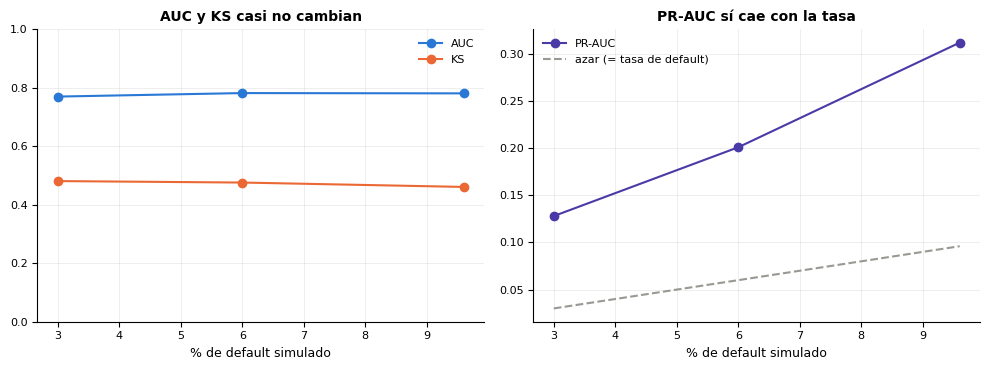

In [94]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
axes[0].plot(sim.index * 100, sim["auc"], marker="o", color=COLORES["train"], label="AUC")
axes[0].plot(sim.index * 100, sim["ks"], marker="o", color=COLORES["valid"], label="KS")
axes[0].set_ylim(0, 1); axes[0].set_xlabel("% de default simulado"); axes[0].set_title("AUC y KS casi no cambian"); axes[0].legend()
axes[1].plot(sim.index * 100, sim["pr_auc"], marker="o", color=COLORES["violeta"], label="PR-AUC")
axes[1].plot(sim.index * 100, sim.index, color=COLORES["gris"], linestyle="--", label="azar (= tasa de default)")
axes[1].set_xlabel("% de default simulado"); axes[1].set_title("PR-AUC sí cae con la tasa"); axes[1].legend()
plt.tight_layout()

Esto confirma que AUC y KS son poco sensibles al balance; PR-AUC no, y por eso se mira siempre contra la tasa base (línea gris).

## Sensibilidades

Pruebas para saber qué tan dependiente es el resultado de decisiones que tomamos: el umbral de mora, los créditos que ya estaban en mora en el primer corte y el número de bins.

In [95]:
# Sensibilidad a la definición de default: el mismo score del modelo A contra otros objetivos (valid)
# mora_ventana (de la sección de variable objetivo) = mora máxima de cada crédito en sus primeros 3 cortes
pA = modelos["A  Logit: base (3 variables)"]["p"]["valid"]
filas = []
for umbral in [30, 60, 90]:
    yv = (valid_w["application_id"].map(mora_ventana) >= umbral).astype(int).values
    a, k = auc_ks(pA, yv)
    filas.append({"default si mora >=": umbral, "eventos_valid": int(yv.sum()), "tasa": yv.mean(), "auc": a, "ks": k})
pd.DataFrame(filas).set_index("default si mora >=").round(3)

,eventos_valid,tasa,auc,ks
default si mora >=,,,,
30,172,0.273,0.619,0.221
60,68,0.108,0.781,0.461
90,32,0.051,0.782,0.568


El mismo score evaluado contra otros objetivos: con mora >= 90 el AUC es igual (0.782) y el KS más alto (0.568, con solo 32 eventos), con mora >= 30 baja a 0.619 porque mora 30 es una etapa donde la mitad de los clientes se cura (51.8% según la matriz de transición), o sea que es un evento más ruidoso. El score funciona a 60 y a 90 y la elección de 60 se sostiene.

In [96]:
# Sensibilidad a los créditos que ya estaban en mora en el primer corte (posible fraude de primer pago)
c1 = cartera_analisis[cartera_analisis["product_type"].notna()].copy()
c1["altura_mora"] = c1["altura_mora"].astype(int)
c1 = c1.sort_values(["application_id", "fecha_corte"])
mora_corte1 = c1.groupby("application_id")["altura_mora"].first()

for d in (train_w, valid_w, test_w):
    d["mora_corte1"] = d["application_id"].map(mora_corte1)
print("Créditos con mora >= 30 ya en el primer corte (train/valid/test):",
      [int((d["mora_corte1"] >= 30).sum()) for d in (train_w, valid_w, test_w)])

filas = []
for nombre, excluir in [("Con todos los créditos", False), ("Sin los de mora en el primer corte", True)]:
    d_tr = train_w[train_w["mora_corte1"] < 30] if excluir else train_w
    d_va = valid_w[valid_w["mora_corte1"] < 30] if excluir else valid_w
    X_tr = modelos["A  Logit: base (3 variables)"]["X"]["train"].loc[d_tr.index]; X_va = modelos["A  Logit: base (3 variables)"]["X"]["valid"].loc[d_va.index]
    m = LogisticRegression(C=np.inf, max_iter=2000).fit(X_tr, d_tr[Y])
    a, k = auc_ks(m.predict_proba(X_va)[:, 1], d_va[Y].values)
    filas.append({"escenario": nombre, "n_valid": len(d_va), "eventos_valid": int(d_va[Y].sum()), "auc_valid": a, "ks_valid": k})
pd.DataFrame(filas).set_index("escenario").round(3)

Créditos con mora >= 30 ya en el primer corte (train/valid/test): [278, 64, 92]


,n_valid,eventos_valid,auc_valid,ks_valid
escenario,,,,
Con todos los créditos,631,68,0.781,0.461
Sin los de mora en el primer corte,567,28,0.762,0.430


Hay 278 créditos en train, 64 en valid y 92 en test que ya estaban en mora >= 30 en su primer corte. Su tasa de default es 51.1% contra 4.7% del resto. Son los candidatos a fraude de primer pago o a clientes que nunca pagaron. Si se excluyen del entrenamiento y de la evaluación, el AUC en valid baja a 0.762 (KS 0.430), pero los eventos de valid caen de 68 a 28: **más de la mitad de los defaults de valid son de este tipo**. El modelo ordena bien incluso sin ellos, pero está mezclando dos fenómenos (riesgo de crédito y posible fraude o no pago inicial) y conviene tratarlos aparte en producción.

In [97]:
# Variables más fuertes entre los créditos que se rodaron desde el primer corte vs el resto (train)
resumen_c1 = train_w.groupby(train_w["mora_corte1"] >= 30)[["avg_monthly_topups", "pago_prom", "has_bureau_record", Y]].mean().round(3)
resumen_c1.index = ["mora < 30 en corte 1", "mora >= 30 en corte 1"]
resumen_c1

,avg_monthly_topups,pago_prom,has_bureau_record,default_60_90d
mora < 30 en corte 1,50652.046,0.75,0.438,0.047
mora >= 30 en corte 1,37696.892,0.73,0.579,0.511


Los de mora en el primer corte tienen menos recargas (37.697 contra 50.652) y más historial en buró (57.9% contra 43.8%), por eso el modelo los captura aun sin saber que son un grupo aparte.

In [98]:
# Robustez de los bins: IV de recargas cambiando el número de bins (train)
iv_bins = {}
for nb_ in [4, 5, 6, 8, 10]:
    spec = fit_bins(train_w["avg_monthly_topups"], n_bins=nb_)
    bt = apply_bins(train_w["avg_monthly_topups"], spec)
    iv_bins[nb_] = round(iv(bt, ytr, woe_map(bt, ytr)), 3)
iv_bins

{4: 0.357, 5: 0.404, 6: 0.435, 8: 0.535, 10: 0.501}

El IV de recargas depende del número de bins (0.357 con 4, 0.435 con 6, 0.535 con 8, 0.501 con 10), pero siempre es alto; con más bins se sobreajusta. Se usan 6 por el equilibrio entre tamaño de bin (unos 440 clientes) y detalle.

## Modelo elegido y evaluación final en test

**Decisión: modelo A**, regresión logística sobre WoE con `avg_monthly_topups`, `pago_prom` y `has_bureau_record`.

* Empata en valid con el boosting (diferencia AUC +0.003 a favor del boosting, IC95% de -0.032 a +0.039), pero tiene muy poco sobreajuste y se puede explicar y auditar variable por variable.
* Ninguna variable adicional (`bureau_score`, las 10 retiradas) la mejora; sumarlas empeora valid.
* Su estructura (3 variables, bins, WoE) se puede pasar a producción como un JSON y reproducir en cualquier sistema.

Ahora sí se usa test, una sola vez.

In [99]:
# Modelo elegido: A (regresión logística sobre WoE con 3 variables). Se evalúa en test UNA sola vez
MODELO_FINAL = modelos["A  Logit: base (3 variables)"]
p_tr, p_va, p_te = MODELO_FINAL["p"]["train"], MODELO_FINAL["p"]["valid"], MODELO_FINAL["p"]["test"]
yte = test_w[Y].values

filas = []
for nombre, p, y in [("train", p_tr, ytr), ("valid", p_va, yva), ("test", p_te, yte)]:
    a, k = auc_ks(p, y)
    filas.append({"split": nombre, "n": len(y), "eventos": int(y.sum()), "tasa_real": y.mean(), "pd_media": p.mean(),
                  "auc": a, "ks": k, "pr_auc": average_precision_score(y, p), "brier": np.mean((p - y) ** 2)})
metricas_finales = pd.DataFrame(filas).set_index("split")
metricas_finales.round(3)

,n,eventos,tasa_real,pd_media,auc,ks,pr_auc,brier
split,,,,,,,,
train,2651,254,0.096,0.096,0.750,0.386,0.219,0.081
valid,631,68,0.108,0.099,0.781,0.461,0.312,0.085
test,648,93,0.144,0.125,0.777,0.473,0.336,0.109


En test el modelo mantiene su desempeño: **AUC 0.777, KS 0.473, PR-AUC 0.336** (valid: 0.781, 0.461, 0.312). La PD media es 12.5% contra 14.4% real: el modelo subestima el riesgo, algo esperado por el corrimiento de octubre que vimos antes.

In [100]:
# IC95% de AUC y KS en test (bootstrap, 1000 remuestras)
r = np.random.default_rng(SEED)
aucs, kss = [], []
for _ in range(1000):
    i = r.integers(0, len(yte), len(yte))
    a, k = auc_ks(p_te[i], yte[i]); aucs.append(a); kss.append(k)
print("AUC test: %.3f  IC95%% (%.3f, %.3f)" % (auc_ks(p_te, yte)[0], *np.percentile(aucs, [2.5, 97.5])))
print("KS  test: %.3f  IC95%% (%.3f, %.3f)" % (auc_ks(p_te, yte)[1], *np.percentile(kss, [2.5, 97.5])))

AUC test: 0.777  IC95% (0.730, 0.821)
KS  test: 0.473  IC95% (0.394, 0.564)


Con 93 eventos en test el intervalo es amplio: AUC entre 0.730 y 0.821 y KS entre 0.394 y 0.564. El resultado de valid cae dentro de estos intervalos, y todo el rango es mejor que azar con claridad.

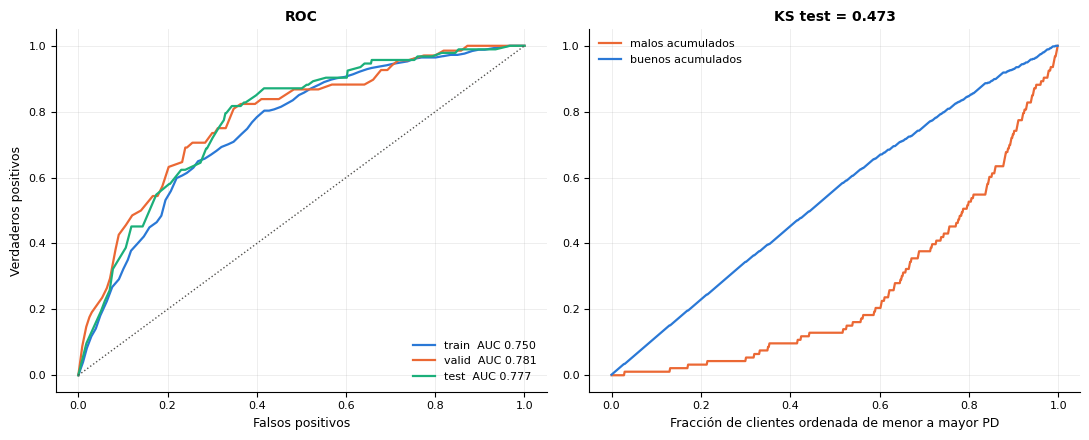

In [101]:
# Curva ROC y curva KS del score en test
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for nombre, p, y, color in [("train", p_tr, ytr, COLORES["train"]), ("valid", p_va, yva, COLORES["valid"]), ("test", p_te, yte, COLORES["test"])]:
    fpr, tpr, _ = roc_curve(y, p)
    axes[0].plot(fpr, tpr, color=color, linewidth=1.6, label=f"{nombre}  AUC {auc_ks(p, y)[0]:.3f}")
axes[0].plot([0, 1], [0, 1], color=COLORES["texto"], linestyle=":", linewidth=1)
axes[0].set_xlabel("Falsos positivos"); axes[0].set_ylabel("Verdaderos positivos"); axes[0].set_title("ROC"); axes[0].legend(loc="lower right")

# Curva KS en test: distribución acumulada de malos y buenos por score
orden = np.argsort(p_te)
malos_acum = np.cumsum(yte[orden] == 1) / (yte == 1).sum()
buenos_acum = np.cumsum(yte[orden] == 0) / (yte == 0).sum()
axes[1].plot(np.arange(len(yte)) / len(yte), malos_acum, color=COLORES["valid"], linewidth=1.6, label="malos acumulados")
axes[1].plot(np.arange(len(yte)) / len(yte), buenos_acum, color=COLORES["train"], linewidth=1.6, label="buenos acumulados")
axes[1].set_xlabel("Fracción de clientes ordenada de menor a mayor PD"); axes[1].set_title(f"KS test = {auc_ks(p_te, yte)[1]:.3f}"); axes[1].legend()
plt.tight_layout()

Las curvas ROC de train, valid y test son muy cercanas: el modelo generaliza. La curva KS muestra que la mayor separación entre malos y buenos se logra con los clientes de PD media-alta.

In [102]:
# Deciles de riesgo en test (decil 1 = menor PD predicha): tasa real y PD predicha
def tabla_deciles(p, y):
    t = pd.DataFrame({"p": p, "y": y})
    t["decil"] = pd.qcut(t["p"].rank(method="first"), 10, labels=range(1, 11))
    t = t.groupby("decil", observed=True).agg(n=("y", "size"), malos=("y", "sum"), tasa_real=("y", "mean"), pd_media=("p", "mean"))
    t["lift"] = t["tasa_real"] / t["malos"].sum() * t["n"].sum()
    return t

dec_te, dec_va = tabla_deciles(p_te, yte), tabla_deciles(p_va, yva)
dec_te.round(3)

,n,malos,tasa_real,pd_media,lift
decil,,,,,
1,65,1,0.015,0.020,0.107
2,65,2,0.031,0.034,0.214
3,65,1,0.015,0.046,0.107
4,64,5,0.078,0.062,0.544
5,65,3,0.046,0.082,0.322
6,65,6,0.092,0.102,0.643
7,64,17,0.266,0.141,1.851
8,65,13,0.200,0.186,1.394
9,65,20,0.308,0.227,2.144


El decil 1 (menor riesgo) tiene 1.5% de default (1 malo en 65 clientes) y el decil 10 tiene 38.5% (25 de 65), 2.7 veces el promedio de test. El orden no es perfecto (el decil 7 con 26.6% queda por encima del 8 con 20.0%) pero con 65 clientes por decil esa diferencia es ruido. La PD predicha del decil 10 es 34.5%, bien cerca de la real.

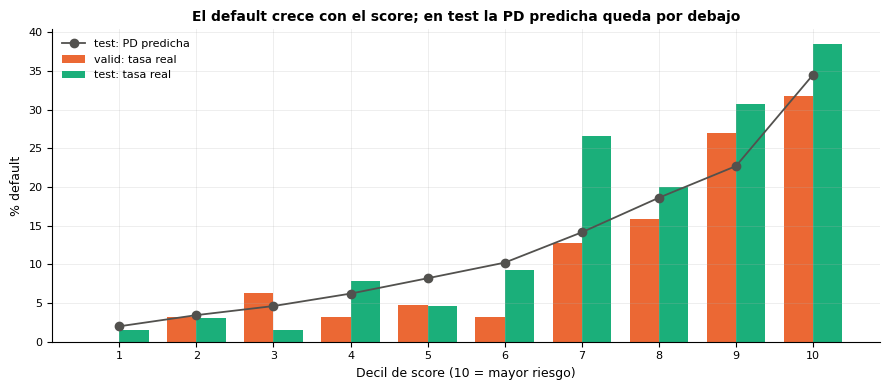

In [103]:
fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(1, 11); ancho = 0.38
ax.bar(x - ancho / 2, dec_va["tasa_real"] * 100, ancho, color=COLORES["valid"], label="valid: tasa real")
ax.bar(x + ancho / 2, dec_te["tasa_real"] * 100, ancho, color=COLORES["test"], label="test: tasa real")
ax.plot(x, dec_te["pd_media"] * 100, color=COLORES["texto"], marker="o", linewidth=1.3, label="test: PD predicha")
ax.set_xticks(x); ax.set_xlabel("Decil de score (10 = mayor riesgo)"); ax.set_ylabel("% default")
ax.set_title("El default crece con el score; en test la PD predicha queda por debajo")
ax.legend(loc="upper left")
plt.tight_layout()

La tasa real sube con el decil en valid y en test (con una inversión entre los deciles 7 y 8 de test, que con 65 clientes por decil es ruido). En test la PD predicha (línea) queda por debajo de la tasa real desde el decil 7.

In [104]:
# Corte de aprobación: se aprueba al X% de clientes con menor PD (el corte se fija con los scores de train)
filas = []
for aprobar in [0.5, 0.6, 0.7, 0.8, 0.9]:
    corte = np.quantile(p_tr, aprobar)
    for nombre, p, y in [("valid", p_va, yva), ("test", p_te, yte)]:
        ap = p <= corte
        filas.append({"split": nombre, "corte_train": f"aprobar menores al P{int(aprobar * 100)}", "aprobados_%": ap.mean() * 100,
                      "default_aprobados_%": y[ap].mean() * 100, "default_rechazados_%": y[~ap].mean() * 100,
                      "malos_evitados_%": (1 - y[ap].sum() / y.sum()) * 100})
cortes = pd.DataFrame(filas).set_index(["split", "corte_train"]).round(1)
cortes

,,aprobados_%,default_aprobados_%,default_rechazados_%,malos_evitados_%
split,corte_train,,,,
valid,aprobar menores al P50,46.6,3.1,17.5,86.8
test,aprobar menores al P50,39.0,3.6,21.3,90.3
valid,aprobar menores al P60,58.6,3.2,21.5,82.4
test,aprobar menores al P60,49.2,3.8,24.6,87.1
valid,aprobar menores al P70,67.8,4.7,23.6,70.6
test,aprobar menores al P70,58.0,4.5,27.9,81.7
valid,aprobar menores al P80,79.2,6.2,28.2,54.4
test,aprobar menores al P80,67.3,7.6,28.3,64.5
valid,aprobar menores al P90,91.4,8.7,33.3,26.5


Usando el corte que aprobaría el 60% en train, en test se aprueba el 49.2% (porque llegan más clientes riesgosos) y el default entre aprobados es 3.8%, contra 14.4% de todos los clientes de test: se evita el 87.1% de los malos. Con el corte P80 se aprueba 67.3% de test con 7.6% de default entre aprobados y se evita el 64.5% de los malos. Es la tabla que sirve para fijar la política de aprobación según el apetito de riesgo.

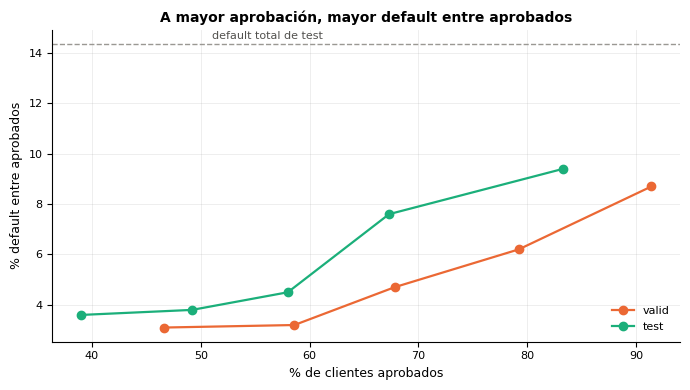

In [105]:
fig, ax = plt.subplots(figsize=(7, 4))
for nombre, color in [("valid", COLORES["valid"]), ("test", COLORES["test"])]:
    t = cortes.loc[nombre]
    ax.plot(t["aprobados_%"], t["default_aprobados_%"], marker="o", color=color, linewidth=1.6, label=nombre)
ax.axhline(yte.mean() * 100, color=COLORES["gris"], linestyle="--", linewidth=1)
ax.text(51, yte.mean() * 100 + 0.2, "default total de test", fontsize=8, color=COLORES["texto"])
ax.set_xlabel("% de clientes aprobados"); ax.set_ylabel("% default entre aprobados")
ax.set_title("A mayor aprobación, mayor default entre aprobados"); ax.legend()
plt.tight_layout()

Aprobar más cuesta más default entre aprobados, y en test cada punto de aprobación cuesta algo más de default que en valid por el cambio en la población.

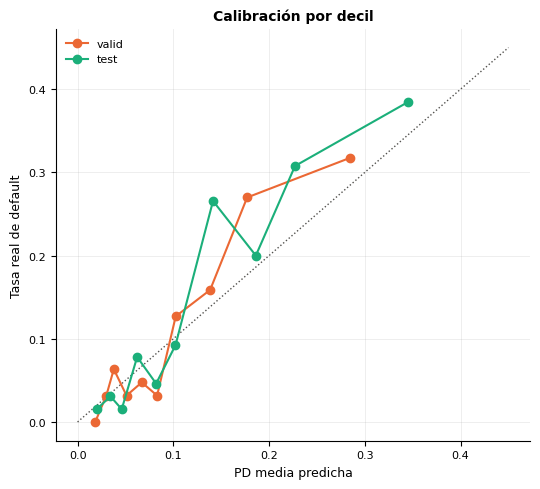

In [106]:
# Calibración: PD predicha vs tasa real por decil (valid y test). Debajo de la diagonal = el modelo subestima el riesgo
fig, ax = plt.subplots(figsize=(5.5, 5))
ax.plot([0, 0.45], [0, 0.45], color=COLORES["texto"], linestyle=":", linewidth=1)
ax.plot(dec_va["pd_media"], dec_va["tasa_real"], marker="o", color=COLORES["valid"], linewidth=1.5, label="valid")
ax.plot(dec_te["pd_media"], dec_te["tasa_real"], marker="o", color=COLORES["test"], linewidth=1.5, label="test")
ax.set_xlabel("PD media predicha"); ax.set_ylabel("Tasa real de default"); ax.set_title("Calibración por decil"); ax.legend()
plt.tight_layout()

En la gráfica de calibración, los deciles de riesgo alto quedan por encima de la diagonal tanto en valid como en test (la tasa real es mayor que la PD predicha), y más en test (decil 10: 38.5% real contra 34.5% predicha). El modelo ordena bien pero está calibrado para la población de train, anterior a octubre.

In [107]:
# ¿Se arregla con un ajuste de calibración? Se ajusta una regresión sobre logit(PD) usando SOLO valid y se aplica a test
logit_p = lambda p: np.log(p / (1 - p)).reshape(-1, 1)
calib = LogisticRegression(C=np.inf).fit(logit_p(p_va), yva)
p_te_cal = calib.predict_proba(logit_p(p_te))[:, 1]
print(f"PD media test: sin calibrar={p_te.mean():.3f} | calibrada con valid={p_te_cal.mean():.3f} | real={yte.mean():.3f}")
print(f"Brier test:    sin calibrar={np.mean((p_te - yte) ** 2):.4f} | calibrada={np.mean((p_te_cal - yte) ** 2):.4f}")
print(f"AUC test:      sin calibrar={auc_ks(p_te, yte)[0]:.3f} | calibrada={auc_ks(p_te_cal, yte)[0]:.3f}  (la calibración no cambia el orden)")

PD media test: sin calibrar=0.125 | calibrada con valid=0.143 | real=0.144
Brier test:    sin calibrar=0.1086 | calibrada=0.1078
AUC test:      sin calibrar=0.777 | calibrada=0.777  (la calibración no cambia el orden)


Una recalibración sencilla con los datos de valid (que ya incluyen un mes con el cambio) corrige el nivel: la PD media de test pasa de 12.5% a 14.3% (real 14.4%), el Brier de 0.1086 a 0.1078 y el AUC no cambia (la calibración no altera el orden). En producción esto se resuelve con recalibración periódica sin reentrenar todo el modelo.

In [108]:
# Estabilidad del score: PSI train vs valid y train vs test, y distribución por decil de train
cortes_dec = np.quantile(p_tr, np.linspace(0, 1, 11)); cortes_dec[0], cortes_dec[-1] = 0, 1
dist = pd.DataFrame({n: pd.Series(pd.cut(p, cortes_dec, include_lowest=True)).value_counts(normalize=True, sort=False).values * 100
                     for n, p in [("train", p_tr), ("valid", p_va), ("test", p_te)]}, index=range(1, 11)).round(1)
print("PSI del score  train vs valid: %.3f | train vs test: %.3f" % (psi(pd.Series(p_tr), pd.Series(p_va)), psi(pd.Series(p_tr), pd.Series(p_te))))
dist

PSI del score  train vs valid: 0.020 | train vs test: 0.142


,train,valid,test
1,10.8,8.6,8.2
2,10.4,10.9,4.6
3,8.8,8.7,9.0
4,10.1,8.6,8.5
5,11.0,9.8,8.8
6,10.6,12.0,10.2
7,8.9,9.2,8.8
8,10.6,11.4,9.3
9,9.3,12.2,16.0
10,9.4,8.6,16.7


El PSI del score es 0.020 entre train y valid (estable) y **0.142 entre train y test** (moderado). La causa es la que ya vimos: en test el 32.7% de los clientes cae en los dos deciles más riesgosos (16.0% y 16.7%) contra 18.7% en train. Es una alerta de monitoreo, no una falla del modelo.

In [109]:
# KS y AUC de las variables principales en los tres splits (mayor valor del score = más riesgo el signo se toma de train)
filas = []
for v in BASE + ["bureau_score"]:
    d_tr = train_w.dropna(subset=[v])
    signo = 1 if auc_ks(d_tr[v].values, d_tr[Y].values)[0] >= 0.5 else -1
    fila = {"variable": v, "sentido": "mayor valor = mayor riesgo" if signo == 1 else "mayor valor = menor riesgo"}
    for nombre, df in [("train", train_w), ("valid", valid_w), ("test", test_w)]:
        d = df.dropna(subset=[v])
        a, k = auc_ks(signo * d[v].values, d[Y].values)
        fila[f"auc_{nombre}"], fila[f"ks_{nombre}"] = a, k
    filas.append(fila)
filas.append({"variable": "SCORE DEL MODELO", "sentido": "PD predicha", **{f"{m}_{n}": auc_ks(p, y)[i] for n, p, y in
              [("train", p_tr, ytr), ("valid", p_va, yva), ("test", p_te, yte)] for i, m in enumerate(["auc", "ks"])}})
tabla_ks_auc = pd.DataFrame(filas).set_index("variable")
tabla_ks_auc.round(3)

,sentido,auc_train,ks_train,auc_valid,ks_valid,auc_test,ks_test
variable,,,,,,,
avg_monthly_topups,mayor valor = menor riesgo,0.692,0.309,0.700,0.363,0.723,0.355
has_bureau_record,mayor valor = mayor riesgo,0.609,0.218,0.629,0.258,0.656,0.311
pago_prom,mayor valor = menor riesgo,0.605,0.162,0.660,0.278,0.580,0.186
bureau_score,mayor valor = menor riesgo,0.509,0.059,0.422,0.252,0.484,0.106
SCORE DEL MODELO,PD predicha,0.750,0.386,0.781,0.461,0.777,0.473


KS y AUC de las variables principales por separado. `avg_monthly_topups` es la más fuerte y estable (AUC 0.692 / 0.700 / 0.723 en train / valid / test; KS 0.309 / 0.363 / 0.355). `has_bureau_record` sube en test (AUC 0.656, KS 0.311). `pago_prom` baja en test (AUC 0.580, KS 0.186) por el corrimiento, y `bureau_score` no pasa de AUC 0.51 en ninguna etapa (0.484 en test). El score del modelo combinado supera a cada variable por separado (AUC 0.750 / 0.781 / 0.777; KS 0.386 / 0.461 / 0.473).

In [110]:
# AUC y KS del score por segmento en test
filas = []
for nombre, mascara in [("sin buró", test_w["has_bureau_record"].values == 0), ("con buró", test_w["has_bureau_record"].values == 1),
                        ("avance_efectivo", test_w["product_type"].values == "avance_efectivo"),
                        ("compra_cartera", test_w["product_type"].values == "compra_cartera"),
                        ("libre_inversion", test_w["product_type"].values == "libre_inversion")]:
    a, k = auc_ks(p_te[mascara], yte[mascara])
    filas.append({"segmento": nombre, "n": int(mascara.sum()), "eventos": int(yte[mascara].sum()), "tasa_real": yte[mascara].mean(),
                  "pd_media": p_te[mascara].mean(), "auc": a, "ks": k})
pd.DataFrame(filas).set_index("segmento").round(3)

,n,eventos,tasa_real,pd_media,auc,ks
segmento,,,,,,
sin buró,333,23,0.069,0.075,0.792,0.563
con buró,315,70,0.222,0.177,0.695,0.312
avance_efectivo,155,16,0.103,0.131,0.808,0.566
compra_cartera,136,18,0.132,0.111,0.831,0.532
libre_inversion,357,59,0.165,0.127,0.751,0.458


Por segmento, el modelo funciona mejor para el cliente **sin buró** (AUC 0.792, KS 0.563, 23 eventos) que para el que tiene buró (AUC 0.695, KS 0.312, 70 eventos), justo la población del piloto. Por producto, el AUC está entre 0.751 (libre inversión) y 0.831 (compra de cartera); con 16 a 59 eventos por producto las diferencias entre productos no son concluyentes.

## Artefactos y reproducibilidad

El modelo se guarda como un JSON con los bins, el WoE de cada bin, los coeficientes y el límite de winsorización. La función `puntuar` calcula la PD de un dataframe crudo leyendo ese archivo, de modo que producción no depende del notebook. Se verifica que reproduce las PD del modelo con diferencia de 1e-16.

In [111]:
# Artefactos: el modelo se guarda como un JSON (bins, WoE, coeficientes) y una función lo aplica a datos crudos
import json, os
os.makedirs("artefactos", exist_ok=True)

def spec_a_json(spec):
    if "bordes" in spec:
        return {"bordes": [float(np.clip(b, -1e18, 1e18)) for b in spec["bordes"]]}
    return {"niveles": [str(n) for n in spec["niveles"]]}

artefacto = {"variable_objetivo": Y, "umbral_mora": UMBRAL_MORA, "ventana_cortes": VENTANA_CORTES, "fin_train": FIN_TRAIN, "fin_valid": FIN_VALID,
             "limite_winsor_p99": {"avg_monthly_topups": float(LIMITE_P99["avg_monthly_topups"])},
             "intercepto": float(MODELO_FINAL["modelo"].intercept_[0]), "variables": {}}
for v, coef in zip(BASE, MODELO_FINAL["modelo"].coef_[0]):
    spec = fit_bins(train_w[v]); bins_train = apply_bins(train_w[v], spec)
    woe = woe_map(bins_train, ytr).reindex(bins_train.cat.categories).fillna(0.0)   # un WoE por bin, en el orden de los bins (el último es NULO)
    artefacto["variables"][v] = {"coeficiente": float(coef), "bins": spec_a_json(spec), "woe_por_bin": [float(w) for w in woe]}
json.dump(artefacto, open("artefactos/modelo_pd.json", "w"), indent=2)

def puntuar(df, ruta="artefactos/modelo_pd.json"):
    """PD de cada fila de un dataframe con las columnas crudas del dataset del candidato."""
    art = json.load(open(ruta))
    d = df.copy()
    d["avg_monthly_topups"] = d["avg_monthly_topups"].clip(upper=art["limite_winsor_p99"]["avg_monthly_topups"])
    d["has_bureau_record"] = d["has_bureau_record"].astype(int)
    d["pago_prom"] = d[["utility_payment_ontime_rate", "telco_payment_ontime_rate"]].mean(axis=1)
    z = np.full(len(d), art["intercepto"])
    for v, info in art["variables"].items():
        posicion = apply_bins(d[v], info["bins"]).cat.codes.values      # número de bin de cada cliente
        z += info["coeficiente"] * np.array(info["woe_por_bin"])[posicion]
    return 1 / (1 + np.exp(-z))

# Verificación: la función reproduce exactamente las PD del modelo
print("Máxima diferencia contra el modelo en test:", np.abs(puntuar(test) - p_te).max())

Máxima diferencia contra el modelo en test: 5.551115123125783e-17


El JSON tiene toda la información del modelo y `puntuar` produce exactamente las mismas PD.

In [112]:
# Se guardan los splits y las métricas para que el resultado sea reproducible
for nombre, df in [("train", train), ("valid", valid), ("test", test)]:
    df.to_csv(f"artefactos/{nombre}.csv", index=False)
pd.concat([metricas_finales.assign(tabla="metricas_finales")]).to_csv("artefactos/metricas_finales.csv")
tabla_iv.to_csv("artefactos/tabla_iv.csv")
sorted(os.listdir("artefactos"))

['metricas_finales.csv',
 'modelo_pd.json',
 'tabla_iv.csv',
 'test.csv',
 'train.csv',
 'valid.csv']

Se guardan en la carpeta `artefactos/`: los tres splits, las métricas finales, la tabla de IV y el JSON del modelo.

## Conclusión

**Modelo elegido: regresión logística sobre WoE con tres variables** (`avg_monthly_topups`, `pago_prom`, `has_bureau_record`).

| Etapa | AUC | KS | PR-AUC |
|---|---|---|---|
| Train | 0.750 | 0.386 | 0.219 |
| Valid | 0.781 | 0.461 | 0.312 |
| Test | 0.777 (IC95% 0.730 a 0.821) | 0.473 (IC95% 0.394 a 0.564) | 0.336 |

**Por qué este modelo y no otro**

* Con 254 eventos en train, los modelos con más variables o más flexibles ganan en train y pierden en valid: el boosting con 13 variables baja de AUC 0.906 a 0.745 y la logística con las 10 variables retiradas de 0.780 a 0.729. El boosting con las 3 variables apenas empata con la logística (+0.003, IC95% de -0.032 a +0.039) y se sobreajusta más.
* Las 10 variables retiradas no superaron el piso de ruido del IV o no se replicaron en valid. `bureau_score` no ordena el riesgo entre quienes lo tienen (AUC 0.509 en train y 0.422 en valid).
* Funciona en la población del piloto: AUC 0.792 en test para clientes sin buró.

**Qué hay que vigilar**

1. **Cambio de población desde octubre de 2024**: el pago a tiempo de servicios baja de 0.75 a 0.67 y el default pasa de 8 a 12% (enero a septiembre) a 12.4% a 14.7% (octubre a diciembre). PSI del score en test 0.142, PD media 12.5% frente a 14.4% real. Se necesita monitoreo mensual del PSI y recalibración periódica del nivel.
2. **Créditos en mora desde el primer corte** (51% de default): más de la mitad de los defaults de valid. Es probable que sea fraude o no pago inicial y conviene separarlo del riesgo de crédito.
3. **Pocos eventos** (93 en test): los intervalos son amplios y las diferencias de menos de 0.03 de AUC entre modelos no son concluyentes.
4. **Sin información de rechazados**: el modelo solo aprende de los créditos desembolsados (3.930); las 70 solicitudes sin desembolso no tienen objetivo y no se pueden evaluar.
5. Antes de producción: reentrenar con train + valid (más eventos), fijar el corte de aprobación según apetito de riesgo con la tabla de cortes y comparar contra una política actual si existe.